In [97]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [98]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()

#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


In [99]:
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []
idx=0
for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):
    idx=idx+1
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "revent": idx,
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [100]:
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta_vec(P, p0, d):
    """
    Distanza di N rette da un punto P (vettorizzato)
    P: (2,) punto
    p0: (N,2) punti sulle rette
    d: (N,2) direzioni delle rette
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])
def compute_intersections_vectorized(rette, event, mcrun):
    """
    Calcola tutte le intersezioni tra rette in modo vettorizzato
    """
    n = len(rette)
    if n < 2:
        return []
    
    # Estrai dati
    p0 = np.array([r["p0"] for r in rette])
    d = np.array([r["d"] for r in rette])
    tel = np.array([r["tel"] for r in rette])
    
    # Genera tutte le coppie (i,j) con i<j
    i_idx, j_idx = np.triu_indices(n, k=1)
    
    # Filtra coppie con stesso telescopio
    same_tel = tel[i_idx] == tel[j_idx]
    valid = ~same_tel
    i_idx = i_idx[valid]
    j_idx = j_idx[valid]
    
    if len(i_idx) == 0:
        return []
    
    # Calcola determinanti
    d1 = d[i_idx]
    d2 = d[j_idx]
    det = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]
    
    # Filtra per parallelismo
    eps_ang = 1e-1
    valid_det = np.abs(det) >= eps_ang
    i_idx = i_idx[valid_det]
    j_idx = j_idx[valid_det]
    det = det[valid_det]
    
    if len(i_idx) == 0:
        return []
    
    # Calcola intersezioni
    p1 = p0[i_idx]
    p2 = p0[j_idx]
    d1 = d[i_idx]
    d2 = d[j_idx]
    
    # Risolvi sistema per ogni coppia
    A_00 = d1[:, 0]
    A_01 = -d2[:, 0]
    A_10 = d1[:, 1]
    A_11 = -d2[:, 1]
    
    detA = A_00*A_11 - A_01*A_10
    eps_det = 1e-6
    valid_detA = np.abs(detA) >= eps_det
    
    i_idx = i_idx[valid_detA]
    j_idx = j_idx[valid_detA]
    detA = detA[valid_detA]
    
    if len(i_idx) == 0:
        return []
    
    # Ricalcola dopo filtro
    p1 = p0[i_idx]
    p2 = p0[j_idx]
    d1 = d[i_idx]
    d2 = d[j_idx]
    A_00 = d1[:, 0]
    A_01 = -d2[:, 0]
    A_10 = d1[:, 1]
    A_11 = -d2[:, 1]
    detA = A_00*A_11 - A_01*A_10
    
    b = p2 - p1
    t = (A_11*b[:, 0] - A_01*b[:, 1]) / detA
    
    P = p1 + t[:, None] * d1
    
    # Costruisci risultati
    inters = []
    for k in range(len(i_idx)):
        inters.append({
            "event": event,
            "mcrun": mcrun,
            "P": P[k],
            "pair": (i_idx[k], j_idx[k])
        })
    
    return inters


# ======================= CALCOLO INTERSEZIONI =======================
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)

for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):
    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values
    
    inters_hg.extend(compute_intersections_vectorized(rette_hg, event, mcrun))
    inters_lg.extend(compute_intersections_vectorized(rette_lg, event, mcrun))

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)


In [101]:
# ======================= CLUSTERING CON OUTLIER REJECTION =======================
from sklearn.cluster import DBSCAN

epsilon = 295
min_samples = 1
centroid_distance_threshold = 1000  # soglia distanza dai baricentri dei telescopi
revent_map = {}
revent_counter = 0


def filter_inter(P, df_evt, p0, threshold=1000):
    """
    Filtra i punti di intersezione in base alla distanza dai baricentri
    dei telescopi che hanno generato l'intersezione.
    
    P: (N, 2) punti di intersezione
    df_evt: DataFrame con colonna 'pair' contenente (i, j) indici telescopi
    p0: (M, 2) baricentri di tutti i telescopi
    threshold: soglia massima di distanza
    
    Returns: maschera booleana dei punti da mantenere
    """
    pairs = np.array(df_evt["pair"].tolist())  # (N, 2)
    
    # Baricentri dei due telescopi per ogni intersezione
    centroid1 = p0[pairs[:, 0]]  # (N, 2)
    centroid2 = p0[pairs[:, 1]]  # (N, 2)
    
    # Distanze dall'intersezione ai due baricentri
    dist1 = np.linalg.norm(P - centroid1, axis=1)
    dist2 = np.linalg.norm(P - centroid2, axis=1)
    
    # Differenza assoluta delle distanze
    diff_dist = np.abs(dist1 - dist2)
    
    # Mantieni solo punti dove la differenza è sotto soglia
    return diff_dist <= threshold
def process_cluster_optimized(P, df_evt, d, p0, tel, centroid_threshold=1000):
    """
    Processa un cluster con filtraggio basato su distanza dai baricentri
    """
    # Calcola pesi angolari
    pairs = np.array(df_evt["pair"].tolist())
    d1 = d[pairs[:, 0]]
    d2 = d[pairs[:, 1]]
    det = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]
    
    # Taglio numerico iniziale
    mask_num = np.abs(det) >= 1e-1
    if not np.any(mask_num):
        return None
    
    # Applica filtro numerico
    P_num = P[mask_num]
    det_num = det[mask_num]
    df_evt_num = df_evt[mask_num].copy()
    
    # Filtro basato su distanza dai baricentri
    mask_centroid = filter_inter(P_num, df_evt_num, p0, centroid_threshold)
    
    if not np.any(mask_centroid):
        return None
    
    # Applica filtro centroidi
    P_filtered = P_num[mask_centroid]
    w = det_num[mask_centroid]**2
    
    if len(P_filtered) < 1:
        return None
    
    # Calcola stimatori finali
    P_simple = np.mean(P_filtered, axis=0)
    P_weight = np.average(P_filtered, axis=0, weights=w)
    P_median = np.median(P_filtered, axis=0)
    
    # Calcola distanze dalle rette
    dist_s = d_punto_retta_vec(P_simple, p0, d)
    dist_w = d_punto_retta_vec(P_weight, p0, d)
    dist_m = d_punto_retta_vec(P_median, p0, d)
    
    return {
        "P_simple": P_simple,
        "P_weight": P_weight,
        "P_median": P_median,
        "dist_s": dist_s,
        "dist_w": dist_w,
        "dist_m": dist_m,
        "delta": np.linalg.norm(P_weight - P_simple),
        "n_points": len(P_filtered),
        "n_rejected": len(P) - len(P_filtered)
    }


# ======================= HG =======================
dist_hg = []
delta_hg = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue
    
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue
    
    dfR_evt = dfR.loc[(dfR["event"] == event) & (dfR["mcrun"] == mcrun), "HG"]
    p0 = np.array([r["p0"] for r in dfR_evt])
    d = np.array([r["d"] for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    
    for lab in cl_labels:
        mask = labels == lab
        Pcl = P[mask]
        dfP = df_evt[mask].copy()
        
        result = process_cluster_optimized(
            Pcl, dfP, d, p0, tel, centroid_distance_threshold
        )
        
        if result is None:
            continue
        
        delta_hg.append(result["delta"])
        
        for t, ds, dw, dm in zip(tel, result["dist_s"], result["dist_w"], result["dist_m"]):
            dist_hg.append({
                "revent": revent,
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": result["P_simple"].copy(),
                "P_weight": result["P_weight"].copy(),
                "P_median": result["P_median"].copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm,
                "n_inliers": result["n_points"],
                "n_rejected": result["n_rejected"]
            })

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []
delta_lg = []

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue
    
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue
    
    dfR_evt = dfR.loc[(dfR["event"] == event) & (dfR["mcrun"] == mcrun), "LG"]
    p0 = np.array([r["p0"] for r in dfR_evt])
    d = np.array([r["d"] for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    
    for lab in cl_labels:
        mask = labels == lab
        Pcl = P[mask]
        dfP = df_evt[mask].copy()
        
        result = process_cluster_optimized(
            Pcl, dfP, d, p0, tel, centroid_distance_threshold
        )
        
        if result is None:
            continue
        
        delta_lg.append(result["delta"])
        
        for t, ds, dw, dm in zip(tel, result["dist_s"], result["dist_w"], result["dist_m"]):
            dist_lg.append({
                "revent": revent,
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": result["P_simple"].copy(),
                "P_weight": result["P_weight"].copy(),
                "P_median": result["P_median"].copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm,
                "n_inliers": result["n_points"],
                "n_rejected": result["n_rejected"]
            })

df_dist_lg = pd.DataFrame(dist_lg)

In [102]:
#=========================== FAKE EVENT ==================================
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]
fake_events = []
fevent_counter = 0
for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
  
    # etichetta evento fittizio con contatore progressivo
    df_fake["FAKE_EVENT"] = fevent_counter
    fevent_counter += 1
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns
#df_fake_all[['FAKE_EVENT', 'EVENT', 'MCRUN']].head(20)

Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [103]:
# ======================= ANALISI FAKE EVENTS =======================

def principal_axis(cov):
    l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
        ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
    theta = np.arctan2(l1 - cov[0,0], cov[0,1])
    return l1, theta


taglio = 0.1

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

results_f = []

for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) == 0:
            continue
        
        # SIGMA-CLIPPING
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results_f.append({
            "event": row["EVENT"],       
            "mcrun": row["MCRUN"],  
            "fevent": int(fevent[0]),   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })

dfR_f = pd.DataFrame(results_f)


# ======================= CALCOLO INTERSEZIONI VETTORIZZATO (FAKE) =======================

def compute_intersections_fake_vectorized(rette, events, mcruns, fevent, taglio=0.1):
    """
    Calcola tutte le intersezioni tra rette per fake events in modo vettorizzato
    """
    n = len(rette)
    if n < 2:
        return []
    
    # Estrai dati
    p0 = np.array([r["p0"] for r in rette])
    d = np.array([r["d"] for r in rette])
    tel = np.array([r["tel"] for r in rette])
    
    # Genera tutte le coppie (i,j) con i<j
    i_idx, j_idx = np.triu_indices(n, k=1)
    
    # Filtra coppie con stesso telescopio
    same_tel = tel[i_idx] == tel[j_idx]
    valid = ~same_tel
    i_idx = i_idx[valid]
    j_idx = j_idx[valid]
    
    if len(i_idx) == 0:
        return []
    
    # Calcola determinanti
    d1 = d[i_idx]
    d2 = d[j_idx]
    det = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]
    
    # Filtra per parallelismo
    valid_det = np.abs(det) >= taglio
    i_idx = i_idx[valid_det]
    j_idx = j_idx[valid_det]
    
    if len(i_idx) == 0:
        return []
    
    # Calcola intersezioni
    p1 = p0[i_idx]
    p2 = p0[j_idx]
    d1 = d[i_idx]
    d2 = d[j_idx]
    
    A_00 = d1[:, 0]
    A_01 = -d2[:, 0]
    A_10 = d1[:, 1]
    A_11 = -d2[:, 1]
    
    detA = A_00*A_11 - A_01*A_10
    eps_det = 1e-6
    valid_detA = np.abs(detA) >= eps_det
    
    i_idx = i_idx[valid_detA]
    j_idx = j_idx[valid_detA]
    detA = detA[valid_detA]
    
    if len(i_idx) == 0:
        return []
    
    # Ricalcola dopo filtro
    p1 = p0[i_idx]
    p2 = p0[j_idx]
    d1 = d[i_idx]
    d2 = d[j_idx]
    A_00 = d1[:, 0]
    A_01 = -d2[:, 0]
    A_10 = d1[:, 1]
    A_11 = -d2[:, 1]
    detA = A_00*A_11 - A_01*A_10
    
    b = p2 - p1
    t = (A_11*b[:, 0] - A_01*b[:, 1]) / detA
    
    P = p1 + t[:, None] * d1
    
    # Costruisci risultati
    inters = []
    for k in range(len(i_idx)):
        inters.append({
            "fevent": fevent,
            "P": P[k],
            "pair": (i_idx[k], j_idx[k]),
            "d1": d[i_idx[k]],
            "d2": d[j_idx[k]],
            "event_i": events[i_idx[k]],
            "mcrun_i": mcruns[i_idx[k]],
            "event_j": events[j_idx[k]],
            "mcrun_j": mcruns[j_idx[k]],
            "tel_i": tel[i_idx[k]],
            "tel_j": tel[j_idx[k]]
        })
    
    return inters


inters_hg_f = []
inters_lg_f = []

for fevent, df_evt in dfR_f.groupby("fevent"):
    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values
    events = df_evt["event"].values
    mcruns = df_evt["mcrun"].values
    
    inters_hg_f.extend(compute_intersections_fake_vectorized(
        rette_hg, events, mcruns, fevent, taglio
    ))
    inters_lg_f.extend(compute_intersections_fake_vectorized(
        rette_lg, events, mcruns, fevent, taglio
    ))

df_int_hg_f = pd.DataFrame(inters_hg_f)
df_int_lg_f = pd.DataFrame(inters_lg_f)

print(df_int_hg_f.columns)
n_points_per_fevent = df_int_hg_f.groupby("fevent").size().reset_index(name="n_points")
print(n_points_per_fevent)


# ======================= CLUSTERING CON OUTLIER REJECTION (FAKE) =======================

# ======================= HG FAKE =======================
dist_hg_f = []
delta_hg_f = []

for fevent, df_evt in df_int_hg_f.groupby("fevent"):
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue
    
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue
    
    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "HG"]
    p0 = np.array([r["p0"] for r in dfR_evt])
    d = np.array([r["d"] for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    
    for lab in cl_labels:
        mask = labels == lab
        Pcl = P[mask]
        dfP = df_evt[mask].copy()
        
        result = process_cluster_optimized(
            Pcl, dfP, d, p0, tel, centroid_distance_threshold
        )
        
        if result is None:
            continue
        
        delta_hg_f.append(result["delta"])
        
        for t, ds, dw, dm in zip(tel, result["dist_s"], result["dist_w"], result["dist_m"]):
            dist_hg_f.append({
                "fevent": fevent,
                "cluster": lab,
                "tel": t,
                "P_simple": result["P_simple"].copy(),
                "P_weight": result["P_weight"].copy(),
                "P_median": result["P_median"].copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm,
                "n_inliers": result["n_points"],
                "n_rejected": result["n_rejected"]
            })

df_dist_hg_f = pd.DataFrame(dist_hg_f)


# ======================= LG FAKE =======================
dist_lg_f = []
delta_lg_f = []

for fevent, df_evt in df_int_lg_f.groupby("fevent"):
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue
    
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue
    
    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "LG"]
    p0 = np.array([r["p0"] for r in dfR_evt])
    d = np.array([r["d"] for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    
    for lab in cl_labels:
        mask = labels == lab
        Pcl = P[mask]
        dfP = df_evt[mask].copy()
        
        result = process_cluster_optimized(
            Pcl, dfP, d, p0, tel, centroid_distance_threshold
        )
        
        if result is None:
            continue
        
        delta_lg_f.append(result["delta"])
        
        for t, ds, dw, dm in zip(tel, result["dist_s"], result["dist_w"], result["dist_m"]):
            dist_lg_f.append({
                "fevent": fevent,
                "cluster": lab,
                "tel": t,
                "P_simple": result["P_simple"].copy(),
                "P_weight": result["P_weight"].copy(),
                "P_median": result["P_median"].copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm,
                "n_inliers": result["n_points"],
                "n_rejected": result["n_rejected"]
            })

df_dist_lg_f = pd.DataFrame(dist_lg_f)

Index(['fevent', 'P', 'pair', 'd1', 'd2', 'event_i', 'mcrun_i', 'event_j',
       'mcrun_j', 'tel_i', 'tel_j'],
      dtype='object')
     fevent  n_points
0         0        16
1         1        11
2         2         5
3         3        20
4         4        18
..      ...       ...
212     212        18
213     213        25
214     214        12
215     215        16
216     216         9

[217 rows x 2 columns]


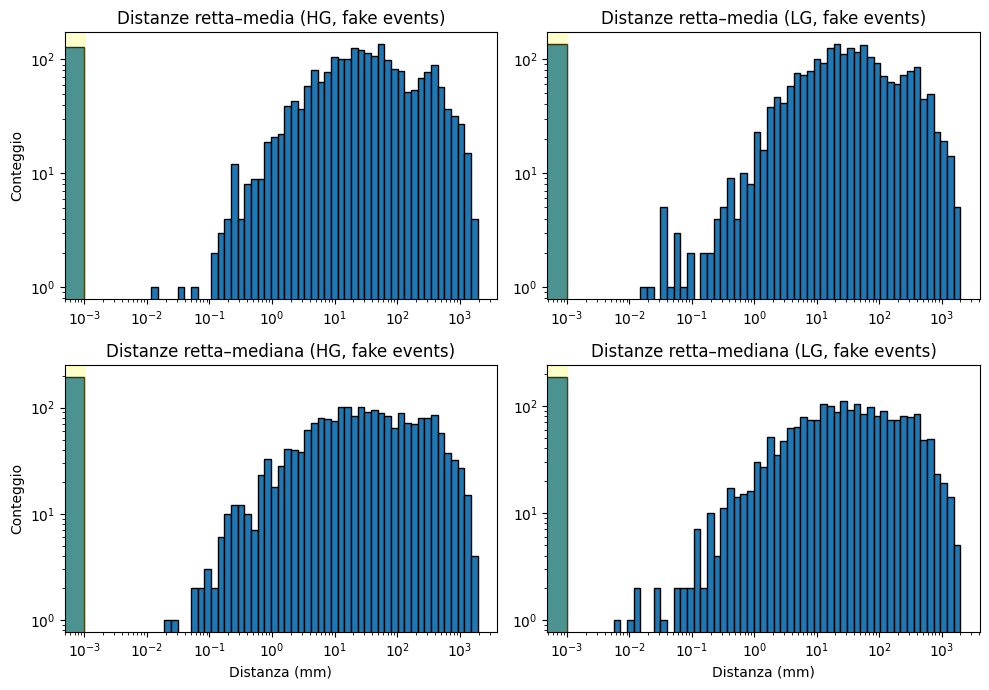

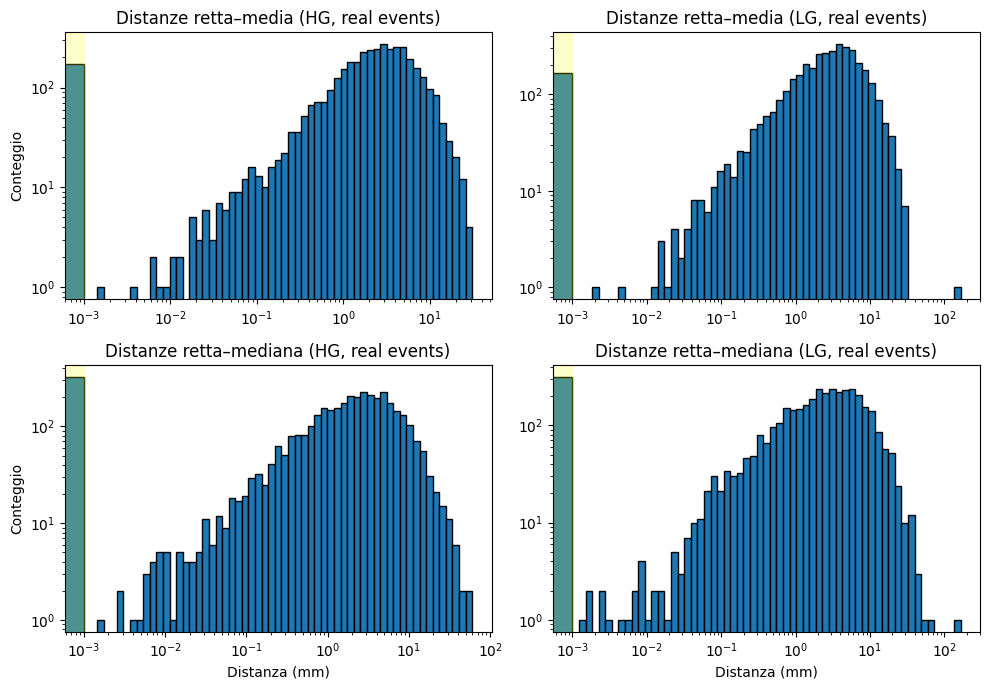

In [104]:
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_f   = df_dist_hg_f["d_weight"].values
d_median_hg_f = df_dist_hg_f["d_median"].values
d_mean_lg_f  = df_dist_lg_f["d_weight"].values
d_median_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg_f   = d_mean_hg_f[np.isfinite(d_mean_hg_f) & (d_mean_hg_f > 0)]
d_median_hg_f = d_median_hg_f[np.isfinite(d_median_hg_f) & (d_median_hg_f > 0)]
d_mean_lg_f   = d_mean_lg_f[np.isfinite(d_mean_lg_f) & (d_mean_lg_f > 0)]
d_median_lg_f = d_median_lg_f[np.isfinite(d_median_lg_f) & (d_median_lg_f > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=60, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg_f)
bins_median_hg = smart_bins(d_median_hg_f)
bins_mean_lg   = smart_bins(d_mean_lg_f)
bins_median_lg = smart_bins(d_median_lg_f)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, fake events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, fake events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, fake events)")

axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, fake events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg  = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=60, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg)
bins_median_hg = smart_bins(d_median_hg)
bins_mean_lg   = smart_bins(d_mean_lg)
bins_median_lg = smart_bins(d_median_lg)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, real events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, real events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, real events)")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, real events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


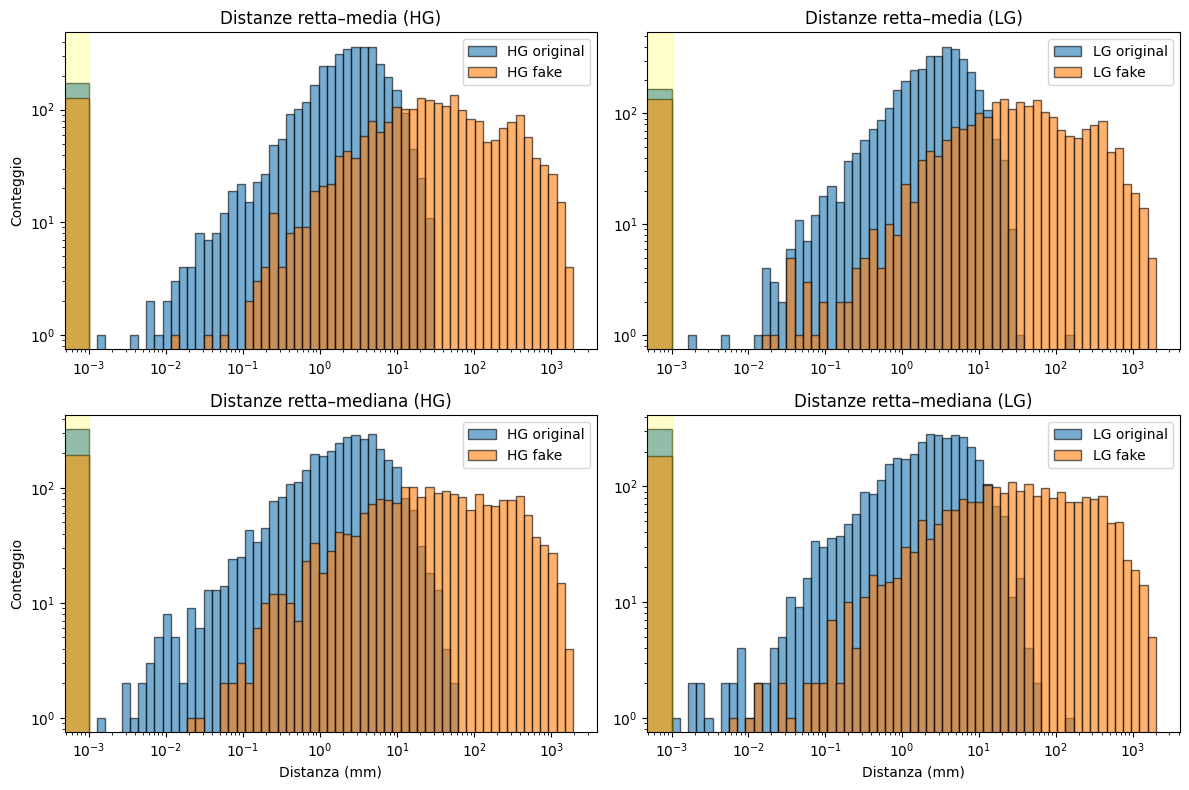

In [105]:


zero_threshold = 0.001
n_bins = 60

def smart_bins(data, n_bins=n_bins, zero_threshold=zero_threshold):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg   = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

d_mean_hg_f   = df_dist_hg_f["d_weight"].values
d_median_hg_f = df_dist_hg_f["d_median"].values
d_mean_lg_f   = df_dist_lg_f["d_weight"].values
d_median_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
datasets = [d_mean_hg, d_median_hg, d_mean_lg, d_median_lg,
            d_mean_hg_f, d_median_hg_f, d_mean_lg_f, d_median_lg_f]

datasets = [d[np.isfinite(d) & (d > 0)] for d in datasets]
d_mean_hg, d_median_hg, d_mean_lg, d_median_lg, \
d_mean_hg_f, d_median_hg_f, d_mean_lg_f, d_median_lg_f = datasets

# ===================== BINS COMUNI =====================
# Calcoliamo un bin comune per ogni tipo di distanza
bins_mean_hg   = smart_bins(np.concatenate([d_mean_hg, d_mean_hg_f]))
bins_median_hg = smart_bins(np.concatenate([d_median_hg, d_median_hg_f]))
bins_mean_lg   = smart_bins(np.concatenate([d_mean_lg, d_mean_lg_f]))
bins_median_lg = smart_bins(np.concatenate([d_median_lg, d_median_lg_f]))

# ===================== PLOT COMPARATIVO =====================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)

# -------------------- HG Mean --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black', alpha=0.6, label='HG original')
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black', alpha=0.6, label='HG fake')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

# -------------------- HG Median --------------------
axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black', alpha=0.6, label='HG original')
axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black', alpha=0.6, label='HG fake')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].legend()

# -------------------- LG Mean --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black', alpha=0.6, label='LG original')
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black', alpha=0.6, label='LG fake')
axes[0,1].set_title("Distanze retta–media (LG)")
axes[0,1].legend()

# -------------------- LG Median --------------------
axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black', alpha=0.6, label='LG original')
axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black', alpha=0.6, label='LG fake')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].legend()

# scala log su entrambi gli assi + evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


In [106]:
print(df_dist_hg_f.columns)

Index(['fevent', 'cluster', 'tel', 'P_simple', 'P_weight', 'P_median',
       'd_simple', 'd_weight', 'd_median', 'n_inliers', 'n_rejected'],
      dtype='object')


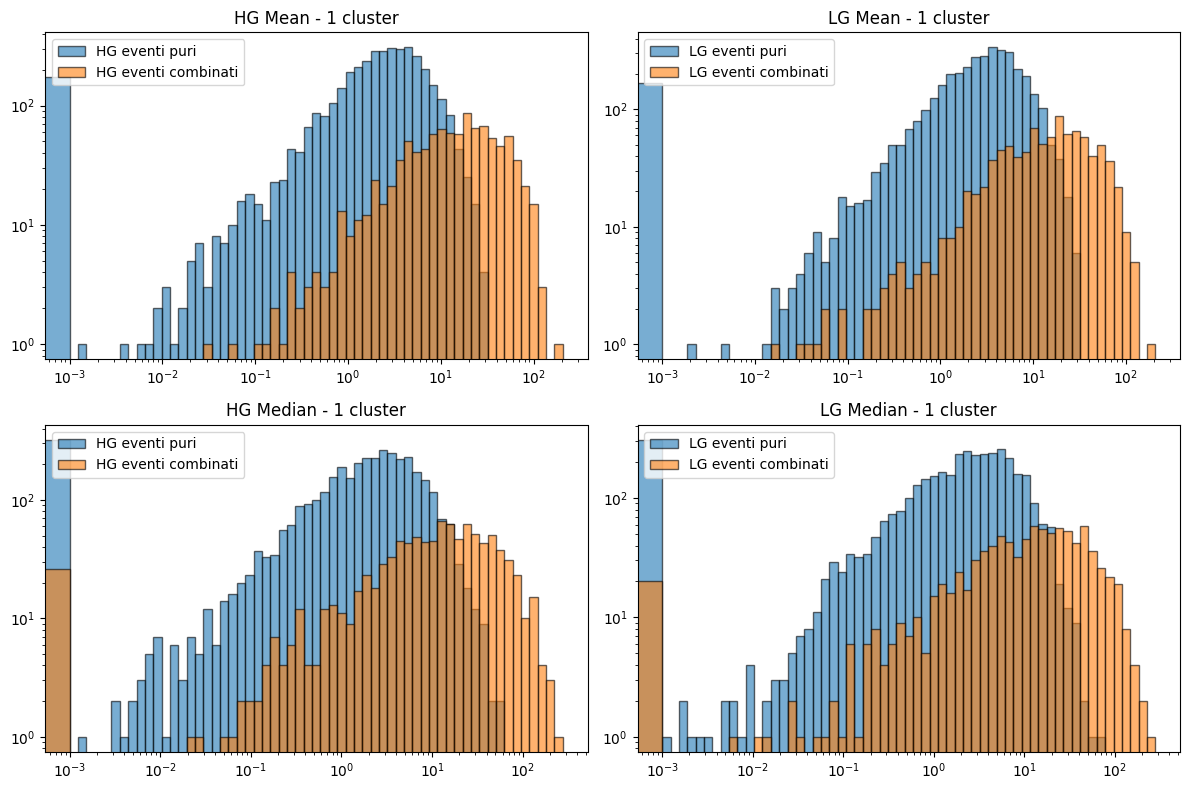

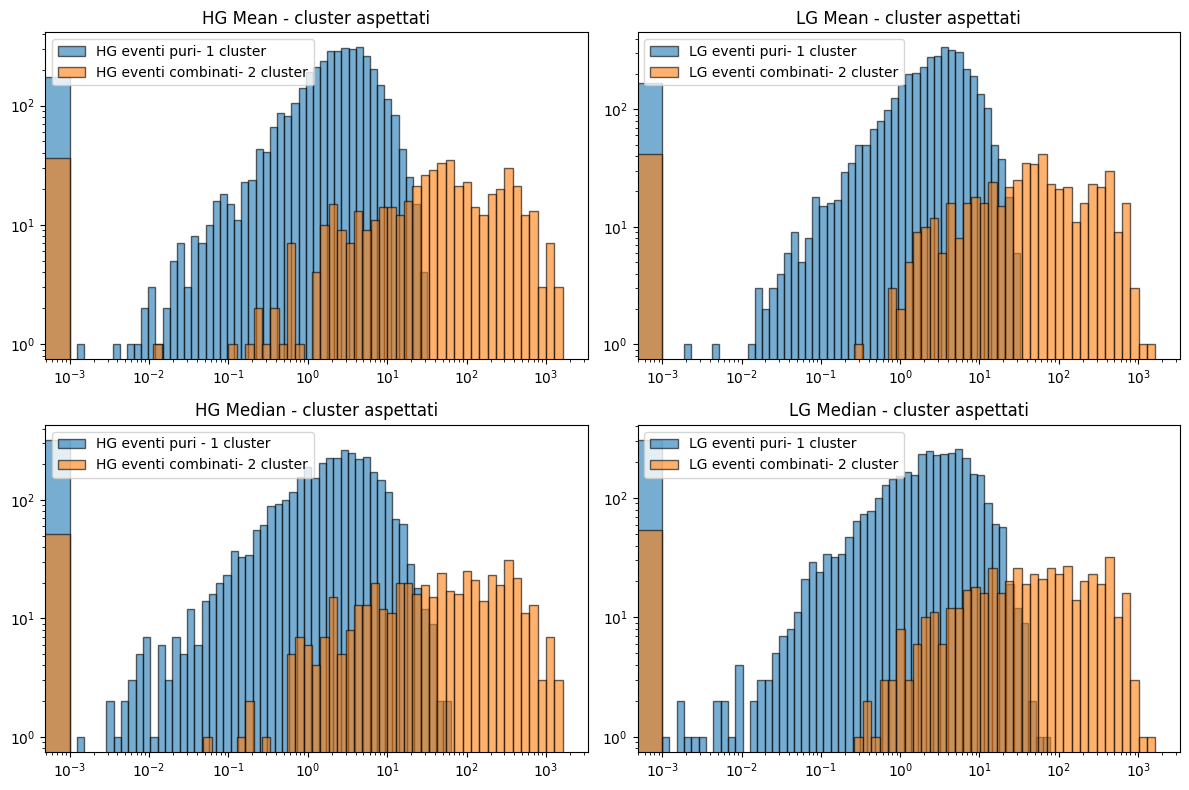

In [107]:
zero_threshold = 0.001
n_bins = 60

# ===================== SELEZIONE EVENTI =====================
# -------------------- Eventi con 1 cluster --------------------
eventi_cluster_hg_1 = df_dist_hg.groupby(["revent"])["cluster"].nunique()
eventi_validi_hg_1 = eventi_cluster_hg_1[eventi_cluster_hg_1 == 1].index
df_sel_hg_1 = df_dist_hg.set_index(["revent"]).loc[eventi_validi_hg_1].reset_index()

eventi_cluster_lg_1 = df_dist_lg.groupby(["revent"])["cluster"].nunique()
eventi_validi_lg_1 = eventi_cluster_lg_1[eventi_cluster_lg_1 == 1].index
df_sel_lg_1 = df_dist_lg.set_index(["revent"]).loc[eventi_validi_lg_1].reset_index()

eventi_cluster_hg_f_1 = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg_f_1 = eventi_cluster_hg_f_1[eventi_cluster_hg_f_1 == 1].index
df_sel_hg_f_1 = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg_f_1].reset_index()

eventi_cluster_lg_f_1 = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg_f_1 = eventi_cluster_lg_f_1[eventi_cluster_lg_f_1 == 1].index
df_sel_lg_f_1 = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg_f_1].reset_index()


# -------------------- Eventi con 2 cluster --------------------
eventi_cluster_hg_2 = df_dist_hg.groupby(["revent"])["cluster"].nunique()
eventi_validi_hg_2 = eventi_cluster_hg_2[eventi_cluster_hg_2 == 2].index
df_sel_hg_2 = df_dist_hg.set_index(["revent"]).loc[eventi_validi_hg_2].reset_index()

eventi_cluster_lg_2 = df_dist_lg.groupby(["revent"])["cluster"].nunique()
eventi_validi_lg_2 = eventi_cluster_lg_2[eventi_cluster_lg_2 == 2].index
df_sel_lg_2 = df_dist_lg.set_index(["revent"]).loc[eventi_validi_lg_2].reset_index()

eventi_cluster_hg_f_2 = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg_f_2 = eventi_cluster_hg_f_2[eventi_cluster_hg_f_2 == 2].index
df_sel_hg_f_2 = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg_f_2].reset_index()

eventi_cluster_lg_f_2 = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg_f_2 = eventi_cluster_lg_f_2[eventi_cluster_lg_f_2 == 2].index
df_sel_lg_f_2 = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg_f_2].reset_index()


# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_1   = df_sel_hg_1["d_weight"].values
d_median_hg_1 = df_sel_hg_1["d_median"].values
d_mean_lg_1   = df_sel_lg_1["d_weight"].values
d_median_lg_1 = df_sel_lg_1["d_median"].values
d_mean_hg_f_1   = df_sel_hg_f_1["d_weight"].values
d_median_hg_f_1 = df_sel_hg_f_1["d_median"].values
d_mean_lg_f_1   = df_sel_lg_f_1["d_weight"].values
d_median_lg_f_1 = df_sel_lg_f_1["d_median"].values

d_mean_hg_2   = df_sel_hg_2["d_weight"].values
d_median_hg_2 = df_sel_hg_2["d_median"].values
d_mean_lg_2   = df_sel_lg_2["d_weight"].values
d_median_lg_2 = df_sel_lg_2["d_median"].values
d_mean_hg_f_2   = df_sel_hg_f_2["d_weight"].values
d_median_hg_f_2 = df_sel_hg_f_2["d_median"].values
d_mean_lg_f_2   = df_sel_lg_f_2["d_weight"].values
d_median_lg_f_2 = df_sel_lg_f_2["d_median"].values

# filtro valori validi (>0 e finiti)
datasets_1 = [d_mean_hg_1, d_median_hg_1, d_mean_lg_1, d_median_lg_1,
              d_mean_hg_f_1, d_median_hg_f_1, d_mean_lg_f_1, d_median_lg_f_1]
datasets_1 = [d[np.isfinite(d) & (d > 0)] for d in datasets_1]
d_mean_hg_1, d_median_hg_1, d_mean_lg_1, d_median_lg_1, \
d_mean_hg_f_1, d_median_hg_f_1, d_mean_lg_f_1, d_median_lg_f_1 = datasets_1

datasets_2 = [d_mean_hg_2, d_median_hg_2, d_mean_lg_2, d_median_lg_2,
              d_mean_hg_f_2, d_median_hg_f_2, d_mean_lg_f_2, d_median_lg_f_2]
datasets_2 = [d[np.isfinite(d) & (d > 0)] for d in datasets_2]
d_mean_hg_2, d_median_hg_2, d_mean_lg_2, d_median_lg_2, \
d_mean_hg_f_2, d_median_hg_f_2, d_mean_lg_f_2, d_median_lg_f_2 = datasets_2

# ===================== BINS COMUNI =====================
bins_mean_hg_1   = smart_bins(np.concatenate([d_mean_hg_1, d_mean_hg_f_1]))
bins_median_hg_1 = smart_bins(np.concatenate([d_median_hg_1, d_median_hg_f_1]))
bins_mean_lg_1   = smart_bins(np.concatenate([d_mean_lg_1, d_mean_lg_f_1]))
bins_median_lg_1 = smart_bins(np.concatenate([d_median_lg_1, d_median_lg_f_1]))

bins_mean_hg_2   = smart_bins(np.concatenate([d_mean_hg_2, d_mean_hg_f_2]))
bins_median_hg_2 = smart_bins(np.concatenate([d_median_hg_2, d_median_hg_f_2]))
bins_mean_lg_2   = smart_bins(np.concatenate([d_mean_lg_2, d_mean_lg_f_2]))
bins_median_lg_2 = smart_bins(np.concatenate([d_median_lg_2, d_median_lg_f_2]))

# ===================== PLOT =====================
# Plot per eventi con 1 cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(d_mean_hg_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.6, label='HG eventi puri')
axes[0,0].hist(d_mean_hg_f_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.6, label='HG eventi combinati')
axes[0,0].set_title("HG Mean - 1 cluster")
axes[0,0].legend()
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_median_hg_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.6, label='HG eventi puri')
axes[1,0].hist(d_median_hg_f_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.6, label='HG eventi combinati')
axes[1,0].set_title("HG Median - 1 cluster")
axes[1,0].legend()
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

axes[0,1].hist(d_mean_lg_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.6, label='LG eventi puri')
axes[0,1].hist(d_mean_lg_f_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.6, label='LG eventi combinati')
axes[0,1].set_title("LG Mean - 1 cluster")
axes[0,1].legend()
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_median_lg_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.6, label='LG eventi puri')
axes[1,1].hist(d_median_lg_f_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.6, label='LG eventi combinati')
axes[1,1].set_title("LG Median - 1 cluster")
axes[1,1].legend()
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()

# Plot per eventi con 2 cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(d_mean_hg_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.6, label='HG eventi puri- 1 cluster')
axes[0,0].hist(d_mean_hg_f_2, bins=bins_mean_hg_2, edgecolor='black', alpha=0.6, label='HG eventi combinati- 2 cluster')
axes[0,0].set_title("HG Mean - cluster aspettati")
axes[0,0].legend()
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_median_hg_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.6, label='HG eventi puri - 1 cluster')
axes[1,0].hist(d_median_hg_f_2, bins=bins_median_hg_2, edgecolor='black', alpha=0.6, label='HG eventi combinati- 2 cluster')
axes[1,0].set_title("HG Median - cluster aspettati")
axes[1,0].legend()
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

axes[0,1].hist(d_mean_lg_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.6, label='LG eventi puri- 1 cluster')
axes[0,1].hist(d_mean_lg_f_2, bins=bins_mean_lg_2, edgecolor='black', alpha=0.6, label='LG eventi combinati- 2 cluster')
axes[0,1].set_title("LG Mean - cluster aspettati")
axes[0,1].legend()
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_median_lg_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.6, label='LG eventi puri- 1 cluster')
axes[1,1].hist(d_median_lg_f_2, bins=bins_median_lg_2, edgecolor='black', alpha=0.6, label='LG eventi combinati- 2 cluster')
axes[1,1].set_title("LG Median - cluster aspettati")
axes[1,1].legend()
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()


In [108]:
thr = 35

# Trova i revent che hanno almeno una distanza > threshold
fevents_big_hg = df_dist_hg[df_dist_hg["d_weight"] > thr]["revent"].unique()

print(f"Fevents con distanze HG > {thr}: {fevents_big_hg}")

# ==================== PLOT ====================
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.40 * diag

# Loop sui primi 3 fevents con distanze grandi
for revent in fevents_big_hg[:3]:
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=1.5, label='Camera footprint', zorder=1)

    # Seleziona tutte le rette di questo revent
    rette_evento = [r for r in results if r["revent"] == revent]

    # Prima pass: plot delle rette in background (trasparenti)
    for r in rette_evento:
        # -------- HG --------
        p0_hg = r["HG"]["p0"]
        d_hg = r["HG"]["d"]
        x1, y1 = p0_hg[0] - L*d_hg[0], p0_hg[1] - L*d_hg[1]
        x2, y2 = p0_hg[0] + L*d_hg[0], p0_hg[1] + L*d_hg[1]
        ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=1.5, alpha=0.4, zorder=2)

        # -------- LG --------
        p0_lg = r["LG"]["p0"]
        d_lg = r["LG"]["d"]
        x1, y1 = p0_lg[0] - L*d_lg[0], p0_lg[1] - L*d_lg[1]
        x2, y2 = p0_lg[0] + L*d_lg[0], p0_lg[1] + L*d_lg[1]
        ax.plot([x1, x2], [y1, y2], color="grey", linewidth=1.5, alpha=0.4, zorder=2)

    # Seconda pass: plot dei centroidi sopra le rette
    for r in rette_evento:
        # Centroidi HG
        p0_hg = r["HG"]["p0"]
        ax.scatter(p0_hg[0], p0_hg[1], s=80, color="firebrick", zorder=5, edgecolor='darkred', linewidth=1)

        # Centroidi LG
        p0_lg = r["LG"]["p0"]
        ax.scatter(p0_lg[0], p0_lg[1], s=60, color="grey", edgecolor="black", linewidth=1, zorder=5)
        ax.scatter(p0[0], p0[1], s=80, color="firebrick", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=2, alpha=0.8)

        # LG
        p0 = r["LG"]["p0"]
        d  = r["LG"]["d"]
        ax.scatter(p0[0], p0[1], s=60, color="grey", edgecolor="black", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="grey", linewidth=2, alpha=0.8)
    
    # Plot dei punti rappresentativi per ogni cluster
    df_fev_hg = df_dist_hg[df_dist_hg["revent"] == revent]
    colors_cluster = ['blue', 'purple', 'cyan', 'magenta', 'orange', 'green']
    
    for idx, cluster_id in enumerate(df_fev_hg["cluster"].unique()):
        color = colors_cluster[idx % len(colors_cluster)]
        
        # Prendi la prima riga del cluster
        df_cluster = df_fev_hg[df_fev_hg["cluster"] == cluster_id].iloc[0]
        
        P_simple = df_cluster["P_simple"]
        P_weight = df_cluster["P_weight"]
        P_median = df_cluster["P_median"]
        
        # Plotta i 3 punti per questo cluster
        ax.scatter(P_simple[0], P_simple[1], s=150, color=color, marker='o', 
                  edgecolor='black', linewidth=2, zorder=10, 
                  label=f"Cluster {cluster_id}")
        ax.scatter(P_weight[0], P_weight[1], s=150, color=color, marker='s', 
                  edgecolor='black', linewidth=2, zorder=10)
        ax.scatter(P_median[0], P_median[1], s=150, color=color, marker='^', 
                  edgecolor='black', linewidth=2, zorder=10)
        
        # Collega i 3 punti
        ax.plot([P_simple[0], P_weight[0], P_median[0]], 
               [P_simple[1], P_weight[1], P_median[1]], 
               color=color, linestyle='--', alpha=0.6, linewidth=1.5, zorder=9)
    
    # Configurazione assi
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X [mm]', fontsize=12)
    ax.set_ylabel('Y [mm]', fontsize=12)
    ax.set_title(f"Fevent {revent} - Rette HG/LG e punti rappresentativi dei cluster", 
                fontsize=14, fontweight='bold')
    
    # Legenda
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='firebrick', linewidth=2, alpha=0.6, label='Rette HG'),
        Line2D([0], [0], color='grey', linewidth=2, alpha=0.6, label='Rette LG'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick', 
               markeredgecolor='darkred', markersize=10, label='Centroidi HG'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', 
               markeredgecolor='black', markersize=9, label='Centroidi LG'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markeredgecolor='black', markersize=12, label='P_simple'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='black', 
               markeredgecolor='black', markersize=12, label='P_weight'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='black', 
               markeredgecolor='black', markersize=12, label='P_median'),
    ]
    
    ax.legend(handles=legend_elements, loc="upper left", fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

Fevents con distanze HG > 35: []


In [109]:
revent_252 = df_dist_hg[df_dist_hg['revent'] == 252][['revent', 'event', 'mcrun']].drop_duplicates()
print(revent_252)

# Oppure, se vuoi vedere tutti i dati per revent=252:
print(df_dist_hg[df_dist_hg['revent'] == 252])

      revent  event   mcrun
1610     252   4116  263455
      revent  event   mcrun  cluster  tel  \
1610     252   4116  263455        0    2   
1611     252   4116  263455        0    5   
1612     252   4116  263455        0    3   
1613     252   4116  263455        0    4   
1614     252   4116  263455        0    6   
1615     252   4116  263455        0    7   
1616     252   4116  263455        0    9   

                                      P_simple  \
1610  [235.77684874185294, 293.38618281304275]   
1611  [235.77684874185294, 293.38618281304275]   
1612  [235.77684874185294, 293.38618281304275]   
1613  [235.77684874185294, 293.38618281304275]   
1614  [235.77684874185294, 293.38618281304275]   
1615  [235.77684874185294, 293.38618281304275]   
1616  [235.77684874185294, 293.38618281304275]   

                                      P_weight  \
1610  [225.43219796141784, 272.31893893917953]   
1611  [225.43219796141784, 272.31893893917953]   
1612  [225.43219796141784, 272.3


MASSIMI DELLE DISTRIBUZIONI A 1 CLUSTER

HG Mean:   28.329
HG Median: 54.606
LG Mean:   30.273
LG Median: 63.353

TAGLIO CONSERVATIVO (max di tutti): 63.353


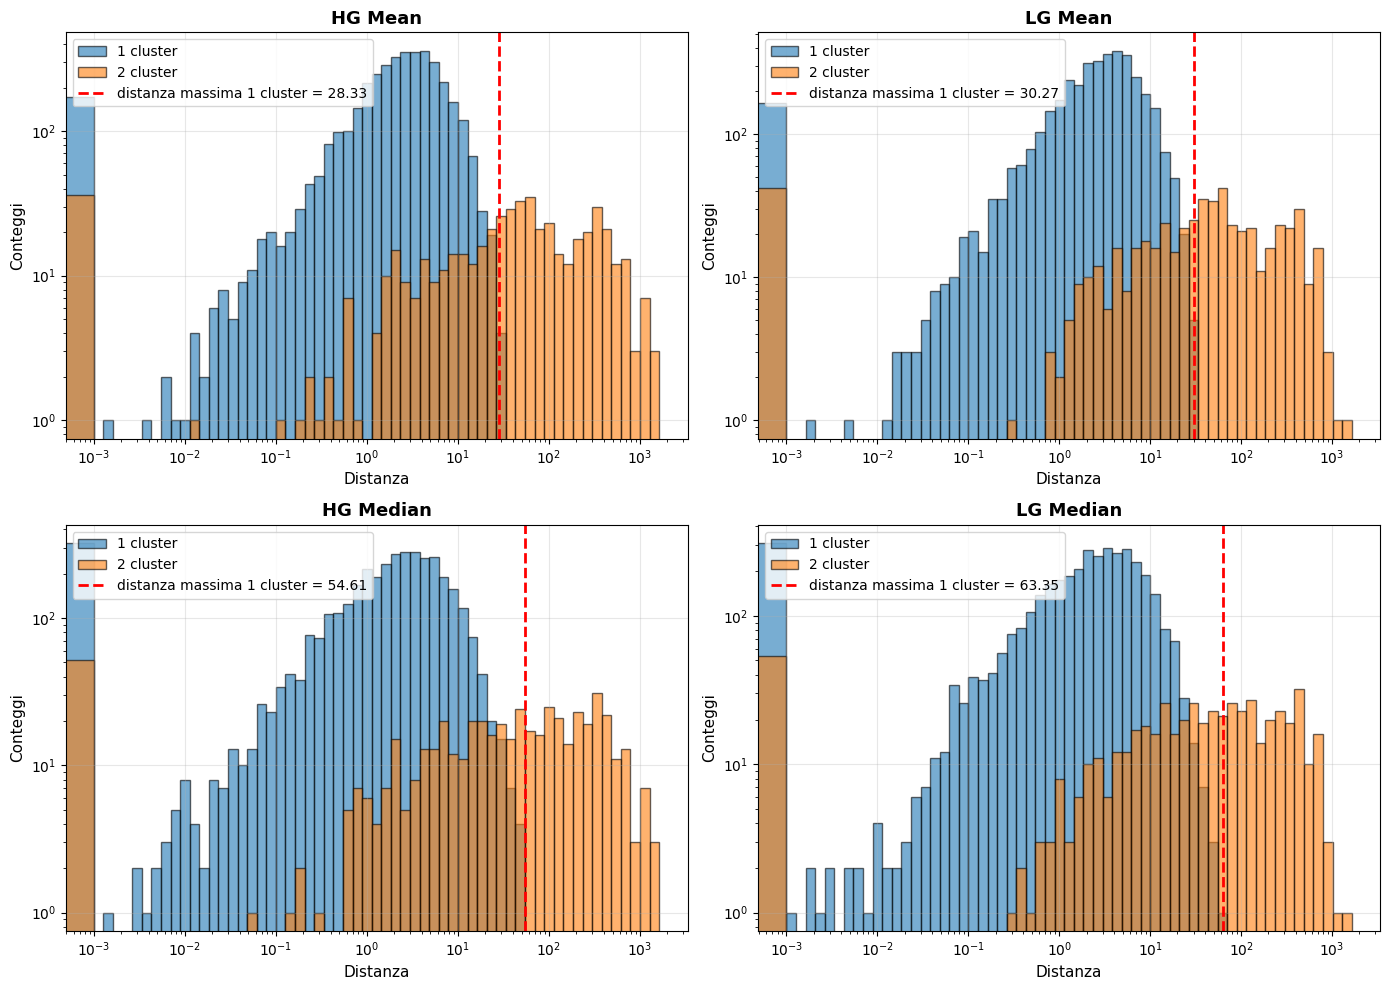


VERIFICA: quanti eventi 2c includi con questi tagli?
HG Mean      (taglio= 28.33):  216/ 528 eventi 2c inclusi ( 40.9%)
HG Median    (taglio= 54.61):  296/ 522 eventi 2c inclusi ( 56.7%)
LG Mean      (taglio= 30.27):  236/ 559 eventi 2c inclusi ( 42.2%)
LG Median    (taglio= 63.35):  326/ 549 eventi 2c inclusi ( 59.4%)


In [110]:

# ===================== CALCOLA I MASSIMI =====================
print("\n" + "="*60)
print("MASSIMI DELLE DISTRIBUZIONI A 1 CLUSTER")
print("="*60)

max_hg_mean = d_mean_hg_1.max()
max_hg_median = d_median_hg_1.max()
max_lg_mean = d_mean_lg_1.max()
max_lg_median = d_median_lg_1.max()

print(f"\nHG Mean:   {max_hg_mean:.3f}")
print(f"HG Median: {max_hg_median:.3f}")
print(f"LG Mean:   {max_lg_mean:.3f}")
print(f"LG Median: {max_lg_median:.3f}")

# Taglio unico conservativo (il più alto)
taglio_conservativo = max(max_hg_mean, max_hg_median, max_lg_mean, max_lg_median)
print(f"\nTAGLIO CONSERVATIVO (max di tutti): {taglio_conservativo:.3f}")

print("="*60)

# ===================== PLOT CON LINEA DI TAGLIO =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_info = [
    (d_mean_hg_1, d_mean_hg_f_2, max_hg_mean, "HG Mean", axes[0,0]),
    (d_median_hg_1, d_median_hg_f_2, max_hg_median, "HG Median", axes[1,0]),
    (d_mean_lg_1, d_mean_lg_f_2, max_lg_mean, "LG Mean", axes[0,1]),
    (d_median_lg_1, d_median_lg_f_2, max_lg_median, "LG Median", axes[1,1])
]

for d_1cluster, d_2cluster, max_val, title, ax in datasets_info:
    bins = smart_bins(np.concatenate([d_1cluster, d_2cluster]))
    
    ax.hist(d_1cluster, bins=bins, edgecolor='black', alpha=0.6, 
            label='1 cluster')
    ax.hist(d_2cluster, bins=bins, edgecolor='black', alpha=0.6, 
            label='2 cluster')
    
    # Linea verticale al massimo
    ax.axvline(max_val, color='red', linestyle='--', linewidth=2, 
               label=f'distanza massima 1 cluster = {max_val:.2f}')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Distanza', fontsize=11)
    ax.set_ylabel('Conteggi', fontsize=11)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== VERIFICA =====================
print("\n" + "="*60)
print("VERIFICA: quanti eventi 2c includi con questi tagli?")
print("="*60)

for name, d_2cluster, max_val in [
    ("HG Mean", d_mean_hg_f_2, max_hg_mean),
    ("HG Median", d_median_hg_f_2, max_hg_median),
    ("LG Mean", d_mean_lg_f_2, max_lg_mean),
    ("LG Median", d_median_lg_f_2, max_lg_median)
]:
    n_inclusi = np.sum(d_2cluster <= max_val)
    perc_inclusi = n_inclusi / len(d_2cluster) * 100
    print(f"{name:12} (taglio={max_val:6.2f}): {n_inclusi:4d}/{len(d_2cluster):4d} eventi 2c inclusi ({perc_inclusi:5.1f}%)")

print("="*60)

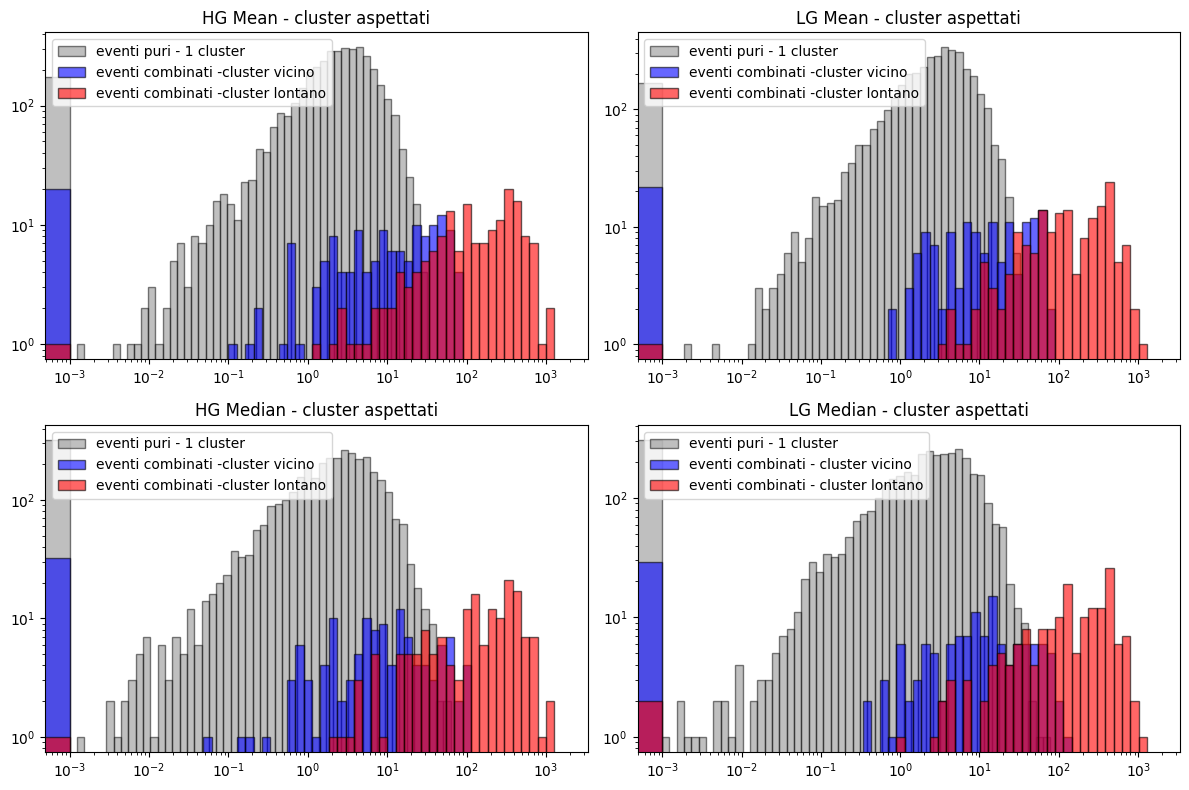

In [111]:
# ===================== CLASSIFICAZIONE CLUSTER VICINO/LONTANO =====================
def classifica_cluster_distanza(df):
    """
    Per ogni (fevent, tel), classifica i cluster come 'vicino' o 'lontano'
    in base alla distanza
    """
    df_class = df.copy()
    df_class['cluster_tipo'] = 'unico'
    
    for (fevent, tel), group in df.groupby(['fevent', 'tel']):
        if len(group) == 2:
            idx_min = group['d_median'].idxmin()  #o d_weight
            idx_max = group['d_median'].idxmax()
            df_class.loc[idx_min, 'cluster_tipo'] = 'vicino'
            df_class.loc[idx_max, 'cluster_tipo'] = 'lontano'
    
    return df_class

df_sel_hg_f_2_class = classifica_cluster_distanza(df_sel_hg_f_2)
df_sel_lg_f_2_class = classifica_cluster_distanza(df_sel_lg_f_2)

# Estrai distanze separate
d_mean_hg_f_2_vicino = df_sel_hg_f_2_class[df_sel_hg_f_2_class['cluster_tipo']=='vicino']['d_weight'].values
d_mean_hg_f_2_lontano = df_sel_hg_f_2_class[df_sel_hg_f_2_class['cluster_tipo']=='lontano']['d_weight'].values

d_median_hg_f_2_vicino = df_sel_hg_f_2_class[df_sel_hg_f_2_class['cluster_tipo']=='vicino']['d_median'].values
d_median_hg_f_2_lontano = df_sel_hg_f_2_class[df_sel_hg_f_2_class['cluster_tipo']=='lontano']['d_median'].values

d_mean_lg_f_2_vicino = df_sel_lg_f_2_class[df_sel_lg_f_2_class['cluster_tipo']=='vicino']['d_weight'].values
d_mean_lg_f_2_lontano = df_sel_lg_f_2_class[df_sel_lg_f_2_class['cluster_tipo']=='lontano']['d_weight'].values

d_median_lg_f_2_vicino = df_sel_lg_f_2_class[df_sel_lg_f_2_class['cluster_tipo']=='vicino']['d_median'].values
d_median_lg_f_2_lontano = df_sel_lg_f_2_class[df_sel_lg_f_2_class['cluster_tipo']=='lontano']['d_median'].values

# Filtra valori validi
d_mean_hg_f_2_vicino = d_mean_hg_f_2_vicino[np.isfinite(d_mean_hg_f_2_vicino) & (d_mean_hg_f_2_vicino > 0)]
d_mean_hg_f_2_lontano = d_mean_hg_f_2_lontano[np.isfinite(d_mean_hg_f_2_lontano) & (d_mean_hg_f_2_lontano > 0)]
d_median_hg_f_2_vicino = d_median_hg_f_2_vicino[np.isfinite(d_median_hg_f_2_vicino) & (d_median_hg_f_2_vicino > 0)]
d_median_hg_f_2_lontano = d_median_hg_f_2_lontano[np.isfinite(d_median_hg_f_2_lontano) & (d_median_hg_f_2_lontano > 0)]

d_mean_lg_f_2_vicino = d_mean_lg_f_2_vicino[np.isfinite(d_mean_lg_f_2_vicino) & (d_mean_lg_f_2_vicino > 0)]
d_mean_lg_f_2_lontano = d_mean_lg_f_2_lontano[np.isfinite(d_mean_lg_f_2_lontano) & (d_mean_lg_f_2_lontano > 0)]
d_median_lg_f_2_vicino = d_median_lg_f_2_vicino[np.isfinite(d_median_lg_f_2_vicino) & (d_median_lg_f_2_vicino > 0)]
d_median_lg_f_2_lontano = d_median_lg_f_2_lontano[np.isfinite(d_median_lg_f_2_lontano) & (d_median_lg_f_2_lontano > 0)]

# ===================== PLOT AGGIORNATO =====================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# HG Mean
axes[0,0].hist(d_mean_hg_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.5, label='eventi puri - 1 cluster', color='gray')
axes[0,0].hist(d_mean_hg_f_2_vicino, bins=bins_mean_hg_2, edgecolor='black', alpha=0.6, label='eventi combinati -cluster vicino', color='blue')
axes[0,0].hist(d_mean_hg_f_2_lontano, bins=bins_mean_hg_2, edgecolor='black', alpha=0.6, label='eventi combinati -cluster lontano', color='red')
axes[0,0].set_title("HG Mean - cluster aspettati")
axes[0,0].legend()
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

# HG Median
axes[1,0].hist(d_median_hg_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.5, label='eventi puri - 1 cluster', color='gray')
axes[1,0].hist(d_median_hg_f_2_vicino, bins=bins_median_hg_2, edgecolor='black', alpha=0.6, label='eventi combinati -cluster vicino', color='blue')
axes[1,0].hist(d_median_hg_f_2_lontano, bins=bins_median_hg_2, edgecolor='black', alpha=0.6, label='eventi combinati -cluster lontano', color='red')
axes[1,0].set_title("HG Median - cluster aspettati")
axes[1,0].legend()
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

# LG Mean
axes[0,1].hist(d_mean_lg_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.5, label='eventi puri - 1 cluster', color='gray')
axes[0,1].hist(d_mean_lg_f_2_vicino, bins=bins_mean_lg_2, edgecolor='black', alpha=0.6, label='eventi combinati -cluster vicino', color='blue')
axes[0,1].hist(d_mean_lg_f_2_lontano, bins=bins_mean_lg_2, edgecolor='black', alpha=0.6, label='eventi combinati -cluster lontano', color='red')
axes[0,1].set_title("LG Mean - cluster aspettati")
axes[0,1].legend()
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

# LG Median
axes[1,1].hist(d_median_lg_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.5, label='eventi puri - 1 cluster', color='gray')
axes[1,1].hist(d_median_lg_f_2_vicino, bins=bins_median_lg_2, edgecolor='black', alpha=0.6, label='eventi combinati - cluster vicino', color='blue')
axes[1,1].hist(d_median_lg_f_2_lontano, bins=bins_median_lg_2, edgecolor='black', alpha=0.6, label='eventi combinati - cluster lontano', color='red')
axes[1,1].set_title("LG Median - cluster aspettati")
axes[1,1].legend()
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()

ANALISI TAGLIO NO-CLUSTER

Tagli candidati:
  HG Mean     : 95°= 10.85 mm,  99°= 17.58 mm
  HG Median   : 95°= 11.80 mm,  99°= 22.33 mm
  LG Mean     : 95°= 11.71 mm,  99°= 19.41 mm
  LG Median   : 95°= 13.18 mm,  99°= 22.51 mm


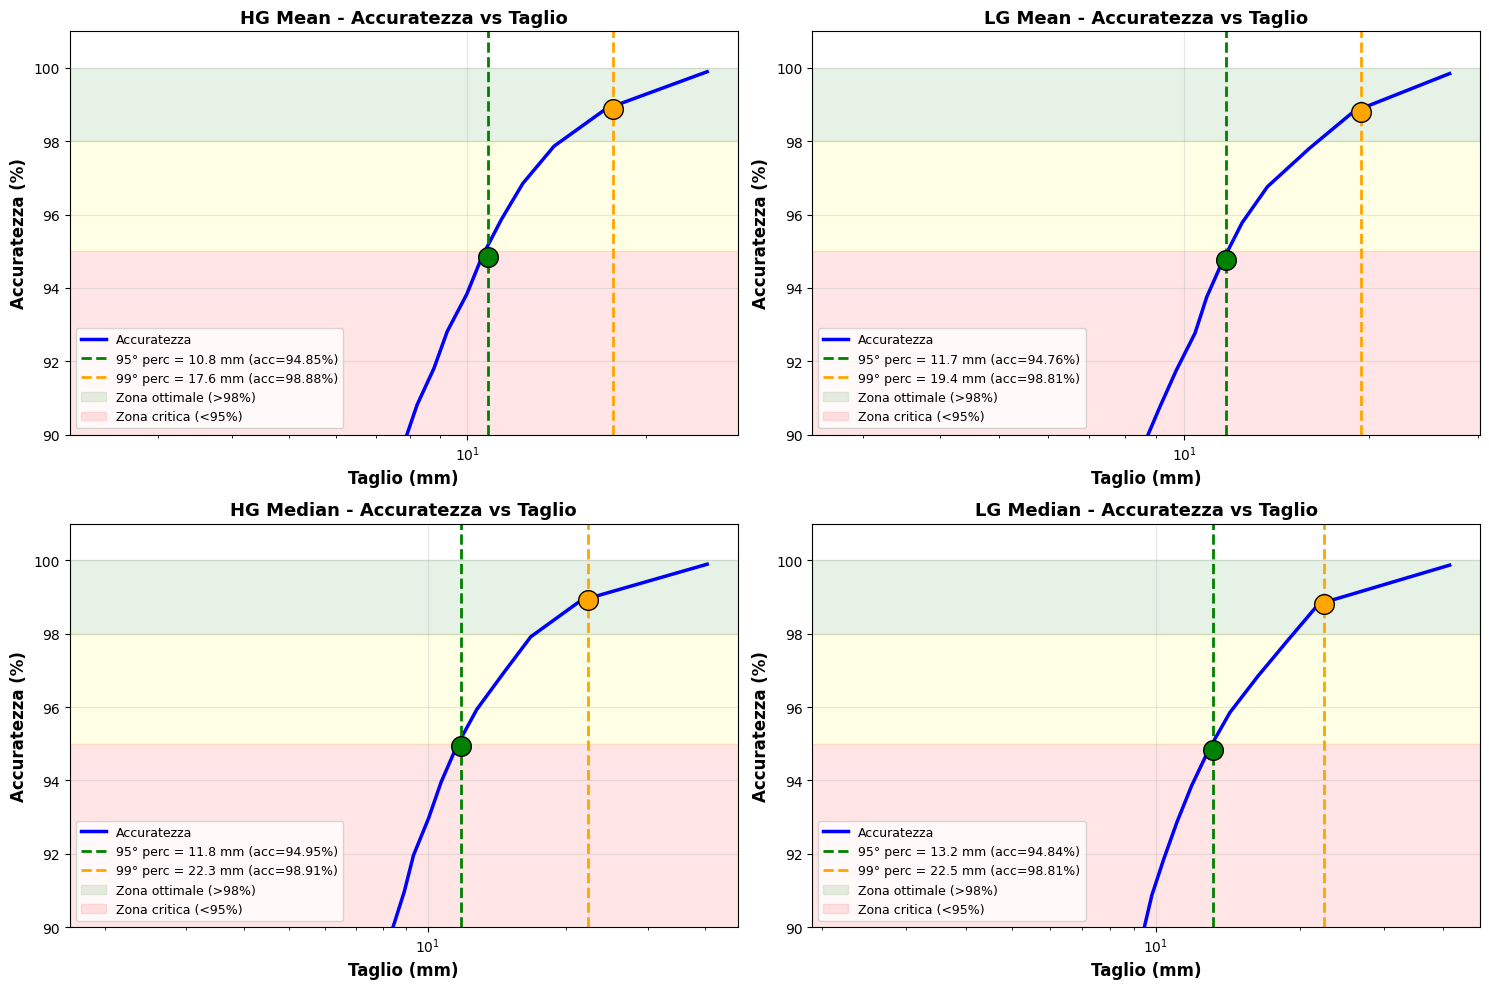

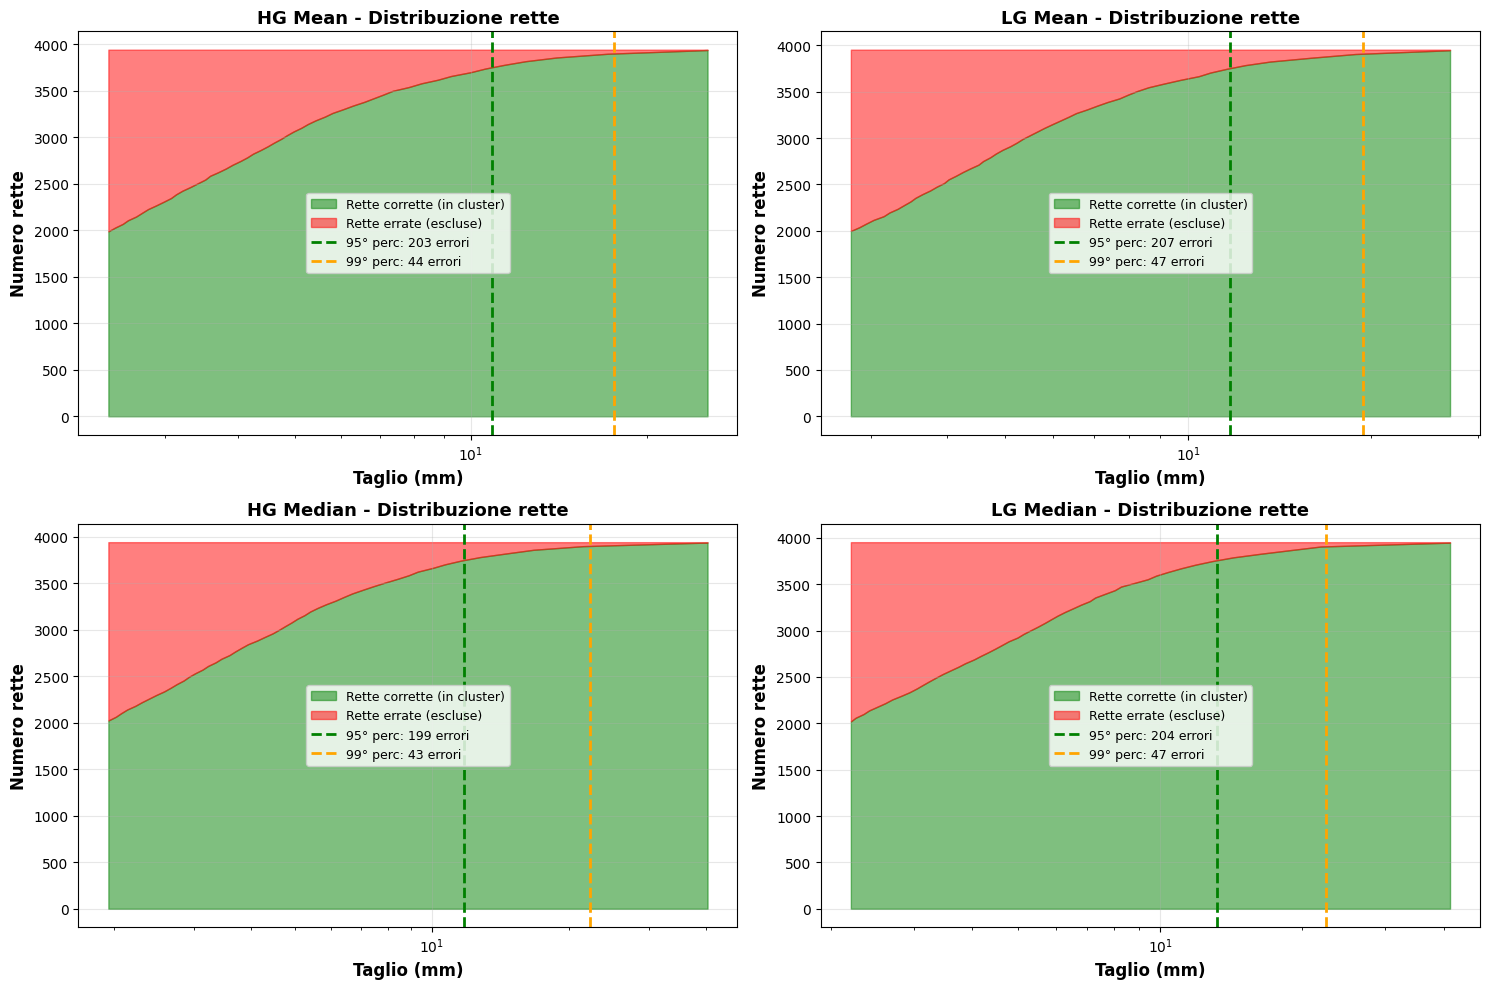


PERFORMANCE DEI TAGLI CANDIDATI

HG MEAN:
Taglio          Valore       Accuratezza     Errori     Puri esclusi   
--------------------------------------------------------------------------------
95° percentile  10.85        95.03           196        5.02%
99° percentile  17.58        98.99           40         1.02%

HG MEDIAN:
Taglio          Valore       Accuratezza     Errori     Puri esclusi   
--------------------------------------------------------------------------------
95° percentile  11.80        95.13           192        5.01%
99° percentile  22.33        99.01           39         1.02%

LG MEAN:
Taglio          Valore       Accuratezza     Errori     Puri esclusi   
--------------------------------------------------------------------------------
95° percentile  11.71        94.97           199        5.00%
99° percentile  19.41        98.94           42         1.00%

LG MEDIAN:
Taglio          Valore       Accuratezza     Errori     Puri esclusi   
--------------------

In [112]:
# ===================== STUDIO TAGLIO "NO CLUSTER" =====================

print("="*80)
print("ANALISI TAGLIO NO-CLUSTER")
print("="*80)

# ===================== CALCOLA TAGLI CANDIDATI =====================
tagli_candidati = {}

# HG Mean
p95_hg_mean = np.percentile(d_mean_hg_1, 95)
p99_hg_mean = np.percentile(d_mean_hg_1, 99)
tagli_candidati['HG Mean'] = {'p95': p95_hg_mean, 'p99': p99_hg_mean}

# HG Median
p95_hg_median = np.percentile(d_median_hg_1, 95)
p99_hg_median = np.percentile(d_median_hg_1, 99)
tagli_candidati['HG Median'] = {'p95': p95_hg_median, 'p99': p99_hg_median}

# LG Mean
p95_lg_mean = np.percentile(d_mean_lg_1, 95)
p99_lg_mean = np.percentile(d_mean_lg_1, 99)
tagli_candidati['LG Mean'] = {'p95': p95_lg_mean, 'p99': p99_lg_mean}

# LG Median
p95_lg_median = np.percentile(d_median_lg_1, 95)
p99_lg_median = np.percentile(d_median_lg_1, 99)
tagli_candidati['LG Median'] = {'p95': p95_lg_median, 'p99': p99_lg_median}

print("\nTagli candidati:")
for metrica, vals in tagli_candidati.items():
    print(f"  {metrica:<12}: 95°={vals['p95']:>6.2f} mm,  99°={vals['p99']:>6.2f} mm")

# ===================== FUNZIONE VERIFICA ACCURATEZZA =====================
def calcola_accuratezza_taglio(df_dist, taglio, metrica_dist='d_weight'):
    """
    Calcola accuratezza del taglio:
    - CORRETTO: retta appartiene al cluster (distanza < taglio) 
    - ERRORE: retta dello stesso (event,mcrun) esclusa (distanza >= taglio)
    
    Returns: (accuratezza %, n_corretti, n_errori, n_totali)
    """
    df_test = df_dist.copy()
    df_test['in_cluster'] = df_test[metrica_dist] < taglio
    
    n_corretti = 0
    n_errori = 0
    
    for (event, mcrun, cluster), df_clust in df_test.groupby(['event', 'mcrun', 'cluster']):
        n_in = (df_clust['in_cluster']).sum()
        n_out = (~df_clust['in_cluster']).sum()
        
        n_corretti += n_in
        n_errori += n_out
    
    n_totali = n_corretti + n_errori
    accuratezza = 100 * n_corretti / n_totali if n_totali > 0 else 0
    
    return accuratezza, n_corretti, n_errori, n_totali

# ===================== SCANSIONE TAGLI PER CURVA ACCURATEZZA =====================
def scansiona_tagli(df_dist, d_puri, metrica_dist='d_weight', n_punti=50):
    """
    Testa diversi valori di taglio e calcola l'accuratezza per ciascuno
    """
    # Range di tagli: dal 50° al 99.9° percentile
    percentili = np.linspace(50, 99.9, n_punti)
    tagli_test = np.percentile(d_puri, percentili)
    
    accuratezze = []
    n_corretti_list = []
    n_errori_list = []
    pct_esclusi_puri = []
    
    for taglio in tagli_test:
        acc, n_corr, n_err, n_tot = calcola_accuratezza_taglio(df_dist, taglio, metrica_dist)
        accuratezze.append(acc)
        n_corretti_list.append(n_corr)
        n_errori_list.append(n_err)
        
        # Quanti eventi puri escluderemmo?
        pct_esclusi = 100 * np.sum(d_puri > taglio) / len(d_puri)
        pct_esclusi_puri.append(pct_esclusi)
    
    return tagli_test, accuratezze, n_corretti_list, n_errori_list, pct_esclusi_puri, percentili

# Scansiona per ogni metrica
tagli_scan_hg_mean, acc_hg_mean, corr_hg_mean, err_hg_mean, escl_hg_mean, perc_hg_mean = \
    scansiona_tagli(df_dist_hg, d_mean_hg_1, 'd_weight')

tagli_scan_hg_median, acc_hg_median, corr_hg_median, err_hg_median, escl_hg_median, perc_hg_median = \
    scansiona_tagli(df_dist_hg, d_median_hg_1, 'd_median')

tagli_scan_lg_mean, acc_lg_mean, corr_lg_mean, err_lg_mean, escl_lg_mean, perc_lg_mean = \
    scansiona_tagli(df_dist_lg, d_mean_lg_1, 'd_weight')

tagli_scan_lg_median, acc_lg_median, corr_lg_median, err_lg_median, escl_lg_median, perc_lg_median = \
    scansiona_tagli(df_dist_lg, d_median_lg_1, 'd_median')

# ===================== GRAFICO ACCURATEZZA VS TAGLIO =====================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

def plot_accuratezza_taglio(ax, tagli, accuratezze, percentili, p95, p99, title):
    # Plot principale: accuratezza vs taglio
    ax.plot(tagli, accuratezze, 'b-', linewidth=2.5, label='Accuratezza')
    
    # Trova indici per p95 e p99
    idx_95 = np.argmin(np.abs(percentili - 95))
    idx_99 = np.argmin(np.abs(percentili - 99))
    
    # Linee verticali per i tagli candidati
    ax.axvline(p95, color='green', linestyle='--', linewidth=2, 
               label=f'95° perc = {p95:.1f} mm (acc={accuratezze[idx_95]:.2f}%)')
    ax.axvline(p99, color='orange', linestyle='--', linewidth=2, 
               label=f'99° perc = {p99:.1f} mm (acc={accuratezze[idx_99]:.2f}%)')
    
    # Punti sui tagli candidati
    ax.scatter([p95], [accuratezze[idx_95]], color='green', s=200, zorder=5, marker='o', edgecolor='black')
    ax.scatter([p99], [accuratezze[idx_99]], color='orange', s=200, zorder=5, marker='o', edgecolor='black')
    
    # Zone colorate
    ax.axhspan(98, 100, alpha=0.1, color='green', label='Zona ottimale (>98%)')
    ax.axhspan(95, 98, alpha=0.1, color='yellow')
    ax.axhspan(0, 95, alpha=0.1, color='red', label='Zona critica (<95%)')
    
    ax.set_xscale('log')
    ax.set_xlabel('Taglio (mm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuratezza (%)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim([90, 101])
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)

plot_accuratezza_taglio(axes[0,0], tagli_scan_hg_mean, acc_hg_mean, perc_hg_mean,
                        p95_hg_mean, p99_hg_mean, "HG Mean - Accuratezza vs Taglio")

plot_accuratezza_taglio(axes[1,0], tagli_scan_hg_median, acc_hg_median, perc_hg_median,
                        p95_hg_median, p99_hg_median, "HG Median - Accuratezza vs Taglio")

plot_accuratezza_taglio(axes[0,1], tagli_scan_lg_mean, acc_lg_mean, perc_lg_mean,
                        p95_lg_mean, p99_lg_mean, "LG Mean - Accuratezza vs Taglio")

plot_accuratezza_taglio(axes[1,1], tagli_scan_lg_median, acc_lg_median, perc_lg_median,
                        p95_lg_median, p99_lg_median, "LG Median - Accuratezza vs Taglio")

plt.tight_layout()
plt.show()

# ===================== GRAFICO ERRORI VS TAGLIO =====================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

def plot_errori_taglio(ax, tagli, n_corretti, n_errori, percentili, p95, p99, title):
    # Stacked bar non funziona bene con tanti punti, usiamo area
    ax.fill_between(tagli, 0, n_corretti, alpha=0.5, color='green', label='Rette corrette (in cluster)')
    ax.fill_between(tagli, n_corretti, np.array(n_corretti)+np.array(n_errori), 
                     alpha=0.5, color='red', label='Rette errate (escluse)')
    
    # Linee verticali
    idx_95 = np.argmin(np.abs(percentili - 95))
    idx_99 = np.argmin(np.abs(percentili - 99))
    
    ax.axvline(p95, color='green', linestyle='--', linewidth=2, 
               label=f'95° perc: {n_errori[idx_95]} errori')
    ax.axvline(p99, color='orange', linestyle='--', linewidth=2, 
               label=f'99° perc: {n_errori[idx_99]} errori')
    
    ax.set_xscale('log')
    ax.set_xlabel('Taglio (mm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Numero rette', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plot_errori_taglio(axes[0,0], tagli_scan_hg_mean, corr_hg_mean, err_hg_mean, perc_hg_mean,
                   p95_hg_mean, p99_hg_mean, "HG Mean - Distribuzione rette")

plot_errori_taglio(axes[1,0], tagli_scan_hg_median, corr_hg_median, err_hg_median, perc_hg_median,
                   p95_hg_median, p99_hg_median, "HG Median - Distribuzione rette")

plot_errori_taglio(axes[0,1], tagli_scan_lg_mean, corr_lg_mean, err_lg_mean, perc_lg_mean,
                   p95_lg_mean, p99_lg_mean, "LG Mean - Distribuzione rette")

plot_errori_taglio(axes[1,1], tagli_scan_lg_median, corr_lg_median, err_lg_median, perc_lg_median,
                   p95_lg_median, p99_lg_median, "LG Median - Distribuzione rette")

plt.tight_layout()
plt.show()

# ===================== TABELLA RIASSUNTIVA =====================
print("\n" + "="*80)
print("PERFORMANCE DEI TAGLI CANDIDATI")
print("="*80)

def stampa_performance_tagli(df_dist, d_puri, p95, p99, metrica_dist, nome):
    print(f"\n{nome}:")
    print(f"{'Taglio':<15} {'Valore':<12} {'Accuratezza':<15} {'Errori':<10} {'Puri esclusi':<15}")
    print("-" * 80)
    
    for nome_taglio, valore in [('95° percentile', p95), ('99° percentile', p99)]:
        acc, n_corr, n_err, n_tot = calcola_accuratezza_taglio(df_dist, valore, metrica_dist)
        pct_escl = 100 * np.sum(d_puri > valore) / len(d_puri)
        
        print(f"{nome_taglio:<15} {valore:<12.2f} {acc:<15.2f} {n_err:<10} {pct_escl:.2f}%")

stampa_performance_tagli(df_dist_hg, d_mean_hg_1, p95_hg_mean, p99_hg_mean, 'd_weight', "HG MEAN")
stampa_performance_tagli(df_dist_hg, d_median_hg_1, p95_hg_median, p99_hg_median, 'd_median', "HG MEDIAN")
stampa_performance_tagli(df_dist_lg, d_mean_lg_1, p95_lg_mean, p99_lg_mean, 'd_weight', "LG MEAN")
stampa_performance_tagli(df_dist_lg, d_median_lg_1, p95_lg_median, p99_lg_median, 'd_median', "LG MEDIAN")

# ===================== SCELTA FINALE =====================
print("\n" + "="*80)
print("RACCOMANDAZIONE")
print("="*80)
print("\nBasandosi sui grafici e sulla tabella:")
print("  - Se vuoi MASSIMA ACCURATEZZA: usa 95° percentile")
print("  - Se vuoi essere PIÙ STRINGENTE (meno falsi negativi): usa 99° percentile")
print("\nTaglio raccomandato: 95° percentile (buon compromesso)")
print("="*80)

# Salva i tagli scelti
taglio_finale_hg_mean = p95_hg_mean
taglio_finale_hg_median = p95_hg_median
taglio_finale_lg_mean = p95_lg_mean
taglio_finale_lg_median = p95_lg_median

print(f"\nTagli finali (95° percentile):")
print(f"  HG Mean:   {taglio_finale_hg_mean:.2f} mm")
print(f"  HG Median: {taglio_finale_hg_median:.2f} mm")
print(f"  LG Mean:   {taglio_finale_lg_mean:.2f} mm")
print(f"  LG Median: {taglio_finale_lg_median:.2f} mm")

In [113]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)
print("=== REAL ===")
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1 = 100 * n_1cl / n_evt if n_evt > 0 else 0
    p2 = 100 * n_2cl / n_evt if n_evt > 0 else 0

    print(f"eps={eps:.1f}: 1 cluster = {p1:.1f}%, 2 cluster = {p2:.1f}%")
print("\n=== FAKE ===")
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1 = 100 * n_1cl / n_evt if n_evt > 0 else 0
    p2 = 100 * n_2cl / n_evt if n_evt > 0 else 0

    print(f"eps={eps:.1f}: 1 cluster = {p1:.1f}%, 2 cluster = {p2:.1f}%")

=== REAL ===


eps=1.0: 1 cluster = 11.7%, 2 cluster = 7.0%
eps=43.1: 1 cluster = 71.5%, 2 cluster = 20.9%
eps=85.1: 1 cluster = 92.2%, 2 cluster = 6.4%
eps=127.2: 1 cluster = 97.2%, 2 cluster = 2.6%
eps=169.2: 1 cluster = 98.4%, 2 cluster = 1.6%
eps=211.3: 1 cluster = 99.2%, 2 cluster = 0.8%
eps=253.3: 1 cluster = 99.8%, 2 cluster = 0.2%
eps=295.4: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=337.4: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=379.5: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=421.5: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=463.6: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=505.6: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=547.7: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=589.7: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=631.8: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=673.8: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=715.9: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=757.9: 1 cluster = 100.0%, 2 cluster = 0.0%
eps=800.0: 1 cluster = 100.0%, 2 cluster = 0.0%

=== FAKE ===
eps=1.0: 1 cluster = 0.0%, 2 cluster

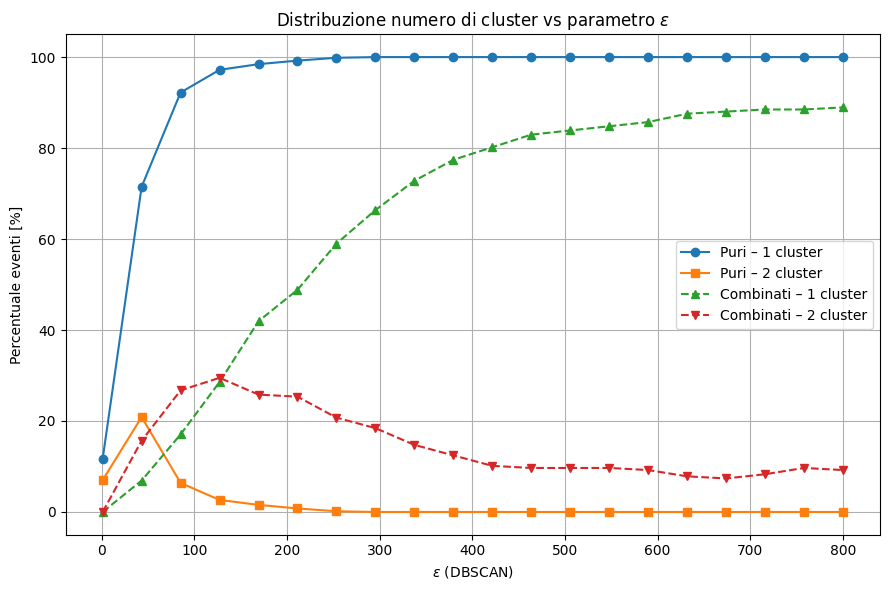

In [114]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)

# ===================== LISTE RISULTATI =====================
p1_real, p2_real = [], []
p1_fake, p2_fake = [], []

# ===================== REAL =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1_real.append(100 * n_1cl / n_evt if n_evt > 0 else 0)
    p2_real.append(100 * n_2cl / n_evt if n_evt > 0 else 0)

# ===================== FAKE =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1_fake.append(100 * n_1cl / n_evt if n_evt > 0 else 0)
    p2_fake.append(100 * n_2cl / n_evt if n_evt > 0 else 0)

# ===================== PLOT =====================
plt.figure(figsize=(9,6))

plt.plot(eps_values, p1_real, marker='o', label="Puri – 1 cluster")
plt.plot(eps_values, p2_real, marker='s', label="Puri – 2 cluster")

plt.plot(eps_values, p1_fake, marker='^', linestyle='--', label="Combinati – 1 cluster")
plt.plot(eps_values, p2_fake, marker='v', linestyle='--', label="Combinati – 2 cluster")

plt.xlabel(r"$\varepsilon$ (DBSCAN)")
plt.ylabel("Percentuale eventi [%]")
plt.title(r"Distribuzione numero di cluster vs parametro $\varepsilon$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


=== EVENTI REAL ===
           eps  n_eventi_totali  n_1cluster  n_2cluster  perc_1cluster  \
0     1.000000              642          75          45      11.682243   
1    43.052632              642         459         134      71.495327   
2    85.105263              642         592          41      92.211838   
3   127.157895              642         624          17      97.196262   
4   169.210526              642         632          10      98.442368   
5   211.263158              642         637           5      99.221184   
6   253.315789              642         641           1      99.844237   
7   295.368421              642         642           0     100.000000   
8   337.421053              642         642           0     100.000000   
9   379.473684              642         642           0     100.000000   
10  421.526316              642         642           0     100.000000   
11  463.578947              642         642           0     100.000000   
12  505.631579    

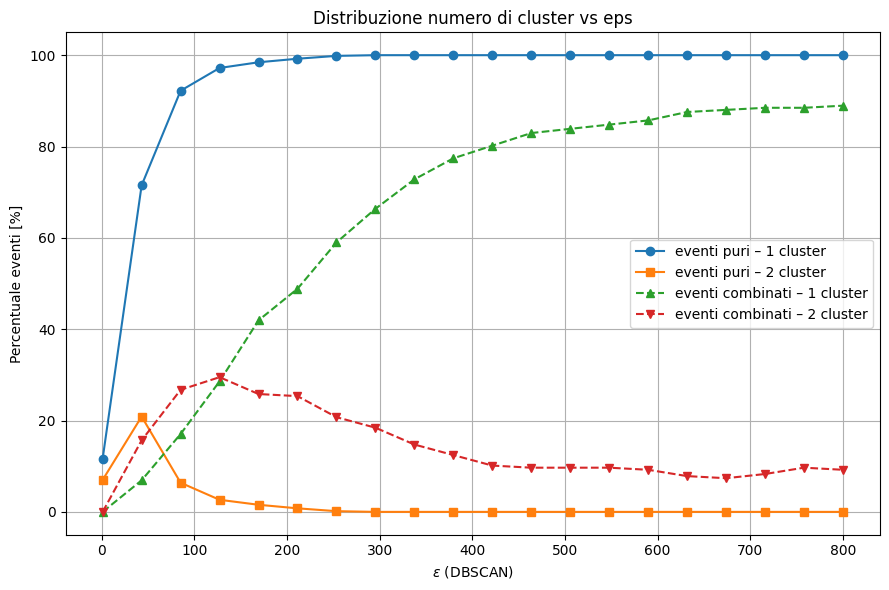


=== Risultati per eps ≈ 211.3 ===
REAL:
  - Eventi con 1 cluster: 637 (99.2%)
  - Eventi con 2 cluster: 5 (0.8%)
FAKE:
  - Eventi con 1 cluster: 106 (48.8%)
  - Eventi con 2 cluster: 55 (25.3%)


In [115]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)

# ===================== LISTE RISULTATI =====================
results_real = []
results_fake = []

# ===================== REAL =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    results_real.append({
        'eps': eps,
        'n_eventi_totali': n_evt,
        'n_1cluster': n_1cl,
        'n_2cluster': n_2cl,
        'perc_1cluster': 100 * n_1cl / n_evt if n_evt > 0 else 0,
        'perc_2cluster': 100 * n_2cl / n_evt if n_evt > 0 else 0
    })

# ===================== FAKE =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    results_fake.append({
        'eps': eps,
        'n_eventi_totali': n_evt,
        'n_1cluster': n_1cl,
        'n_2cluster': n_2cl,
        'perc_1cluster': 100 * n_1cl / n_evt if n_evt > 0 else 0,
        'perc_2cluster': 100 * n_2cl / n_evt if n_evt > 0 else 0
    })

# Converti in DataFrame per facilità di uso
df_results_real = pd.DataFrame(results_real)
df_results_fake = pd.DataFrame(results_fake)

# ===================== VISUALIZZA RISULTATI =====================
print("=== EVENTI REAL ===")
print(df_results_real)
print("\n=== EVENTI FAKE ===")
print(df_results_fake)

# ===================== PLOT =====================
plt.figure(figsize=(9,6))

plt.plot(df_results_real['eps'], df_results_real['perc_1cluster'], 
         marker='o', label="eventi puri – 1 cluster")
plt.plot(df_results_real['eps'], df_results_real['perc_2cluster'], 
         marker='s', label="eventi puri – 2 cluster")

plt.plot(df_results_fake['eps'], df_results_fake['perc_1cluster'], 
         marker='^', linestyle='--', label="eventi combinati – 1 cluster")
plt.plot(df_results_fake['eps'], df_results_fake['perc_2cluster'], 
         marker='v', linestyle='--', label="eventi combinati – 2 cluster")

plt.xlabel(r"$\varepsilon$ (DBSCAN)")
plt.ylabel("Percentuale eventi [%]")
plt.title("Distribuzione numero di cluster vs eps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===================== ESEMPI DI USO =====================
# Per un eps specifico (es. eps=200)
eps_target = 200
idx = np.argmin(np.abs(df_results_real['eps'] - eps_target))

print(f"\n=== Risultati per eps ≈ {df_results_real.loc[idx, 'eps']:.1f} ===")
print(f"REAL:")
print(f"  - Eventi con 1 cluster: {df_results_real.loc[idx, 'n_1cluster']} "
      f"({df_results_real.loc[idx, 'perc_1cluster']:.1f}%)")
print(f"  - Eventi con 2 cluster: {df_results_real.loc[idx, 'n_2cluster']} "
      f"({df_results_real.loc[idx, 'perc_2cluster']:.1f}%)")
print(f"FAKE:")
print(f"  - Eventi con 1 cluster: {df_results_fake.loc[idx, 'n_1cluster']} "
      f"({df_results_fake.loc[idx, 'perc_1cluster']:.1f}%)")
print(f"  - Eventi con 2 cluster: {df_results_fake.loc[idx, 'n_2cluster']} "
      f"({df_results_fake.loc[idx, 'perc_2cluster']:.1f}%)")


Eventi totali nella finestra temporale:
  Stesso evento (same): 22913 (99.6%)
  Eventi diversi (different): 82 (0.4%)


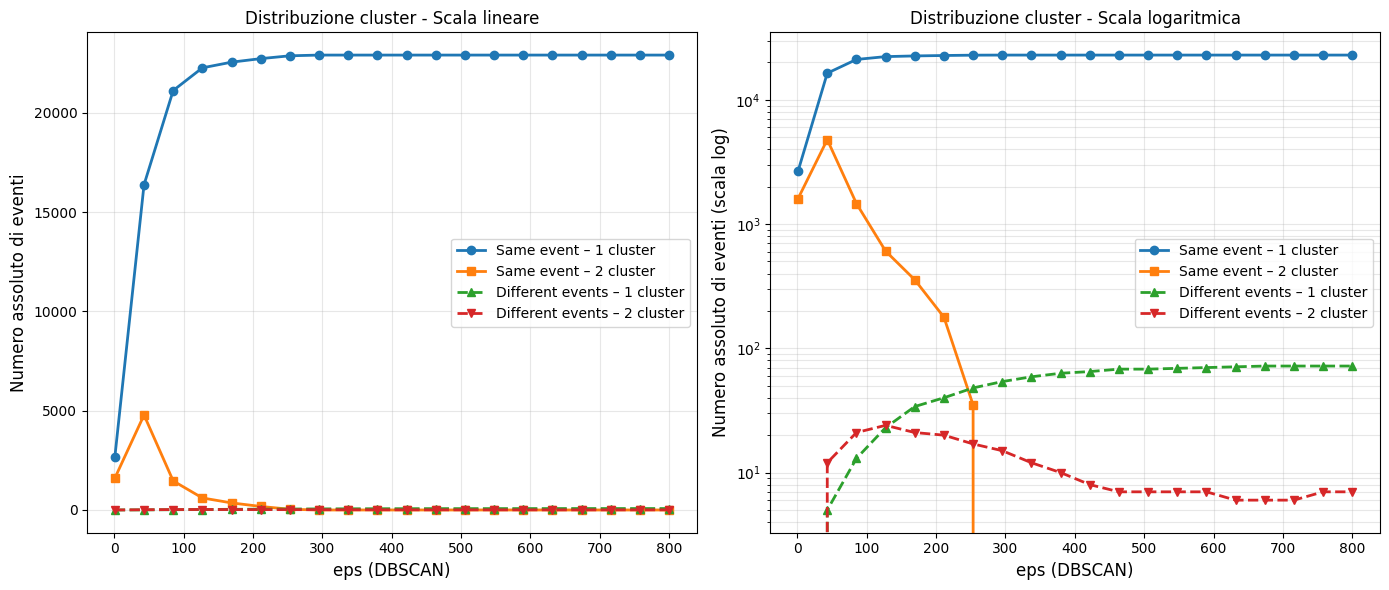


=== Numeri assoluti stimati per alcuni eps ===

eps ≈ 85.1:
  Same event → 1 cluster: 21128 eventi
  Same event → 2 cluster: 1463 eventi
  Different events → 1 cluster: 13 eventi
  Different events → 2 cluster: 21 eventi
  Totale same: 22591
  Totale different: 34

eps ≈ 211.3:
  Same event → 1 cluster: 22734 eventi
  Same event → 2 cluster: 178 eventi
  Different events → 1 cluster: 40 eventi
  Different events → 2 cluster: 20 eventi
  Totale same: 22912
  Totale different: 60

eps ≈ 379.5:
  Same event → 1 cluster: 22913 eventi
  Same event → 2 cluster: 0 eventi
  Different events → 1 cluster: 63 eventi
  Different events → 2 cluster: 10 eventi
  Totale same: 22913
  Totale different: 73

eps ≈ 589.7:
  Same event → 1 cluster: 22913 eventi
  Same event → 2 cluster: 0 eventi
  Different events → 1 cluster: 70 eventi
  Different events → 2 cluster: 7 eventi
  Totale same: 22913
  Totale different: 77


In [116]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)

# ===================== PESI DALLA FINESTRA TEMPORALE =====================
n_same = 22913
n_diff = 82
n_total = 22995

print(f"Eventi totali nella finestra temporale:")
print(f"  Stesso evento (same): {n_same} ({n_same/n_total*100:.1f}%)")
print(f"  Eventi diversi (different): {n_diff} ({n_diff/n_total*100:.1f}%)")

# ===================== LISTE RISULTATI ASSOLUTI =====================
n1_real_abs = []
n2_real_abs = []
n1_fake_abs = []
n2_fake_abs = []

# ===================== REAL (moltiplicato per n_same) =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    # Moltiplica per n_same per ottenere numeri assoluti stimati
    n1_real_abs.append(int(n_same * n_1cl / n_evt) if n_evt > 0 else 0)
    n2_real_abs.append(int(n_same * n_2cl / n_evt) if n_evt > 0 else 0)

# ===================== FAKE (moltiplicato per n_diff) =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    # Moltiplica per n_diff per ottenere numeri assoluti stimati
    n1_fake_abs.append(int(n_diff * n_1cl / n_evt) if n_evt > 0 else 0)
    n2_fake_abs.append(int(n_diff * n_2cl / n_evt) if n_evt > 0 else 0)

# ===================== PLOT CON SCALA LOGARITMICA =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Scala normale (per vedere i same events)
ax1.plot(eps_values, n1_real_abs, marker='o', linewidth=2, label="Same event – 1 cluster")
ax1.plot(eps_values, n2_real_abs, marker='s', linewidth=2, label="Same event – 2 cluster")
ax1.plot(eps_values, n1_fake_abs, marker='^', linewidth=2, linestyle='--', label="Different events – 1 cluster")
ax1.plot(eps_values, n2_fake_abs, marker='v', linewidth=2, linestyle='--', label="Different events – 2 cluster")

ax1.set_xlabel("eps (DBSCAN)", fontsize=12)
ax1.set_ylabel("Numero assoluto di eventi", fontsize=12)
ax1.set_title("Distribuzione cluster - Scala lineare")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Scala logaritmica (per vedere i different events)
ax2.plot(eps_values, n1_real_abs, marker='o', linewidth=2, label="Same event – 1 cluster")
ax2.plot(eps_values, n2_real_abs, marker='s', linewidth=2, label="Same event – 2 cluster")
ax2.plot(eps_values, n1_fake_abs, marker='^', linewidth=2, linestyle='--', label="Different events – 1 cluster")
ax2.plot(eps_values, n2_fake_abs, marker='v', linewidth=2, linestyle='--', label="Different events – 2 cluster")

ax2.set_xlabel("eps (DBSCAN)", fontsize=12)
ax2.set_ylabel("Numero assoluto di eventi (scala log)", fontsize=12)
ax2.set_title("Distribuzione cluster - Scala logaritmica")
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

plt.tight_layout()
plt.show()

# ===================== STAMPA VALORI PER ALCUNI EPS =====================
print("\n=== Numeri assoluti stimati per alcuni eps ===")
for eps_target in [100, 200, 400, 600]:
    idx = np.argmin(np.abs(eps_values - eps_target))
    print(f"\neps ≈ {eps_values[idx]:.1f}:")
    print(f"  Same event → 1 cluster: {n1_real_abs[idx]} eventi")
    print(f"  Same event → 2 cluster: {n2_real_abs[idx]} eventi")
    print(f"  Different events → 1 cluster: {n1_fake_abs[idx]} eventi")
    print(f"  Different events → 2 cluster: {n2_fake_abs[idx]} eventi")
    print(f"  Totale same: {n1_real_abs[idx] + n2_real_abs[idx]}")
    print(f"  Totale different: {n1_fake_abs[idx] + n2_fake_abs[idx]}")

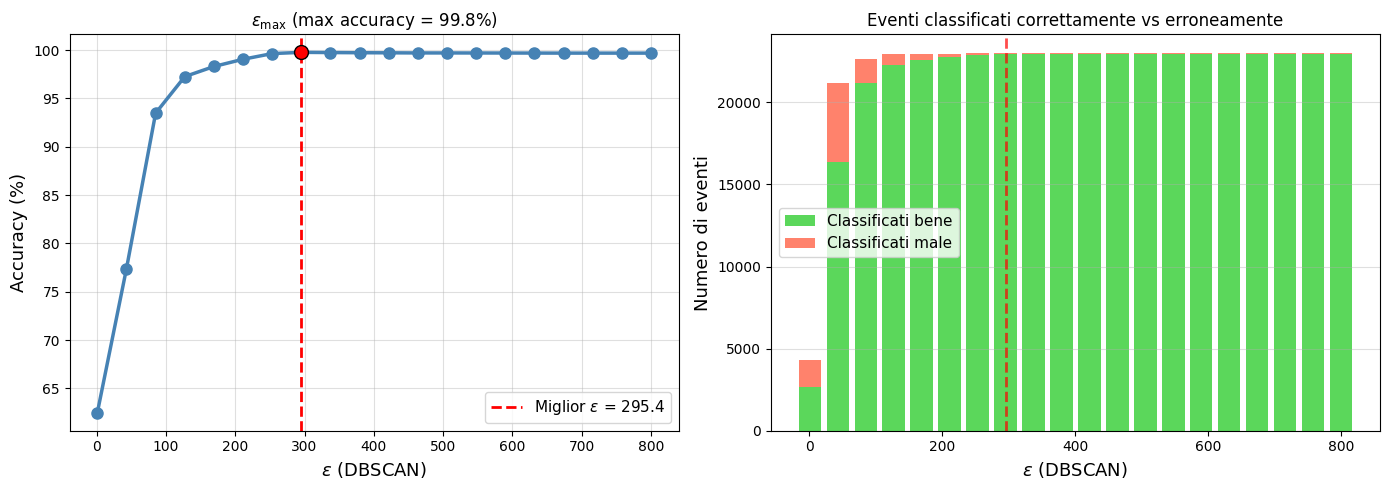

Miglior eps: 295.4
Accuracy: 99.8%

A questo eps:
  Same event(1 cluster): 22913/22913 eventi
  Same event(2 cluster): 0/22913 eventi
  Different events(1 cluster): 54/82 eventi
  Different events(2 cluster): 15/82 eventi

Totale:
  Classificati BENE: 22928/22995
  Classificati MALE: 54/22995


In [117]:
# ===================== CALCOLA ACCURACY =====================
accuracies = []
corretti = []
sbagliati = []

for i in range(len(eps_values)):
    # Corretti: same→1cluster + different→2cluster
    correct = n1_real_abs[i] + n2_fake_abs[i]
    # Sbagliati: same→2cluster + different→1cluster
    wrong = n2_real_abs[i] + n1_fake_abs[i]
    
    accuracy = 100 * correct / (correct + wrong) if (correct + wrong) > 0 else 0
    
    accuracies.append(accuracy)
    corretti.append(correct)
    sbagliati.append(wrong)

# Trova il miglior eps
idx_best = np.argmax(accuracies)
eps_best = eps_values[idx_best]
acc_best = accuracies[idx_best]

# ===================== GRAFICO SEMPLICE =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Accuracy
ax1.plot(eps_values, accuracies, marker='o', linewidth=2.5, markersize=8, color='steelblue')
ax1.axvline(eps_best, color='red', linestyle='--', linewidth=2, label= rf'Miglior $\varepsilon$ = {eps_best:.1f}')
ax1.scatter(eps_best, acc_best, color='red', s=100, zorder=5, marker='o', edgecolor='black')
ax1.set_xlabel(r"$\varepsilon$ (DBSCAN)", fontsize=13)
ax1.set_ylabel('Accuracy (%)', fontsize=13)
ax1.set_title(fr"$\varepsilon_{{\mathrm{{max}}}}$ (max accuracy = {acc_best:.1f}%)")
ax1.grid(True, alpha=0.4)
ax1.legend(fontsize=11)

# Grafico 2: Corretti vs Sbagliati
width = (eps_values[1] - eps_values[0]) * 0.8
ax2.bar(eps_values, corretti, width, label='Classificati bene', color='limegreen', alpha=0.8)
ax2.bar(eps_values, sbagliati, width, bottom=corretti, label='Classificati male', color='tomato', alpha=0.8)
ax2.axvline(eps_best, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_xlabel(r"$\varepsilon$ (DBSCAN)", fontsize=13)
ax2.set_ylabel('Numero di eventi', fontsize=13)
ax2.set_title('Eventi classificati correttamente vs erroneamente')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

print(f"Miglior eps: {eps_best:.1f}")
print(f"Accuracy: {acc_best:.1f}%")
print(f"\nA questo eps:")
print(f"  Same event(1 cluster): {n1_real_abs[idx_best]}/{n_same} eventi")
print(f"  Same event(2 cluster): {n2_real_abs[idx_best]}/{n_same} eventi")
print(f"  Different events(1 cluster): {n1_fake_abs[idx_best]}/{n_diff} eventi")
print(f"  Different events(2 cluster): {n2_fake_abs[idx_best]}/{n_diff} eventi")
print(f"\nTotale:")
print(f"  Classificati BENE: {corretti[idx_best]}/{n_total}")
print(f"  Classificati MALE: {sbagliati[idx_best]}/{n_total}")




In [118]:
# ===================== PREPARAZIONE DATI =====================
df_analysis = pd.DataFrame({
    'eps': eps_values,
    'same_1cl': n1_real_abs,
    'same_2cl': n2_real_abs,
    'diff_1cl': n1_fake_abs,
    'diff_2cl': n2_fake_abs
})

# Calcola metriche di performance
df_analysis['correct'] = df_analysis['same_1cl'] + df_analysis['diff_2cl']
df_analysis['wrong'] = df_analysis['same_2cl'] + df_analysis['diff_1cl']
df_analysis['accuracy'] = 100 * df_analysis['correct'] / (df_analysis['correct'] + df_analysis['wrong'])

# Percentuali sul proprio tipo
df_analysis['same_1cl_pct'] = 100 * df_analysis['same_1cl'] / n_same
df_analysis['diff_2cl_pct'] = 100 * df_analysis['diff_2cl'] / n_diff

# Score pesato
df_analysis['score'] = (df_analysis['same_1cl_pct'] * p_same + 
                        df_analysis['diff_2cl_pct'] * p_diff)

# ===================== VISUALIZZAZIONE 1: STACKED BAR CHART =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Eventi corretti vs sbagliati
ax1 = axes[0, 0]
width = (eps_values[1] - eps_values[0]) * 0.8
ax1.bar(eps_values, df_analysis['correct'], width, label='Corretti', color='green', alpha=0.7)
ax1.bar(eps_values, df_analysis['wrong'], width, bottom=df_analysis['correct'], 
        label='Sbagliati', color='red', alpha=0.7)
ax1.set_xlabel('eps (DBSCAN)', fontsize=11)
ax1.set_ylabel('Numero eventi', fontsize=11)
ax1.set_title('Eventi corretti vs sbagliati', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy
ax2 = axes[0, 1]
ax2.plot(eps_values, df_analysis['accuracy'], marker='o', linewidth=2, 
         color='purple', markersize=8)
ax2.fill_between(eps_values, df_analysis['accuracy'], alpha=0.3, color='purple')
idx_best = df_analysis['accuracy'].idxmax()
ax2.axvline(df_analysis.loc[idx_best, 'eps'], color='red', linestyle='--', 
            label=f"Best eps={df_analysis.loc[idx_best, 'eps']:.1f}")
ax2.scatter(df_analysis.loc[idx_best, 'eps'], df_analysis.loc[idx_best, 'accuracy'], 
            color='red', s=200, zorder=5, marker='*')
ax2.set_xlabel('eps (DBSCAN)', fontsize=11)
ax2.set_ylabel('Accuracy [%]', fontsize=11)
ax2.set_title(f'Accuracy globale (max={df_analysis.loc[idx_best, "accuracy"]:.2f}%)', 
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Success rate per tipo
ax3 = axes[1, 0]
ax3.plot(eps_values, df_analysis['same_1cl_pct'], marker='o', linewidth=2, 
         label='Same → 1 cluster', color='blue')
ax3.plot(eps_values, df_analysis['diff_2cl_pct'], marker='s', linewidth=2, 
         label='Different → 2 cluster', color='orange')
ax3.axvline(df_analysis.loc[idx_best, 'eps'], color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('eps (DBSCAN)', fontsize=11)
ax3.set_ylabel('Success rate [%]', fontsize=11)
ax3.set_title('Performance per tipo di evento', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Confusion matrix style per alcuni eps
ax4 = axes[1, 1]
eps_to_show = [100, 200, 400, 600]
x_pos = np.arange(len(eps_to_show))
width = 0.2

for i, eps_target in enumerate(eps_to_show):
    idx = np.argmin(np.abs(eps_values - eps_target))
    
    # Crea le barre per questo eps
    same_1 = df_analysis.loc[idx, 'same_1cl']
    same_2 = df_analysis.loc[idx, 'same_2cl']
    diff_1 = df_analysis.loc[idx, 'diff_1cl']
    diff_2 = df_analysis.loc[idx, 'diff_2cl']
    
    # Scala logaritmica per visualizzare meglio i different
    ax4.bar(x_pos[i] - width*1.5, same_1, width, label='Same→1cl' if i==0 else '', 
            color='green', alpha=0.7)
    ax4.bar(x_pos[i] - width*0.5, same_2, width, label='Same→2cl' if i==0 else '', 
            color='lightcoral', alpha=0.7)
    ax4.bar(x_pos[i] + width*0.5, diff_1, width, label='Diff→1cl' if i==0 else '', 
            color='red', alpha=0.7)
    ax4.bar(x_pos[i] + width*1.5, diff_2, width, label='Diff→2cl' if i==0 else '', 
            color='lightgreen', alpha=0.7)

ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'eps≈{int(e)}' for e in eps_to_show])
ax4.set_ylabel('Numero eventi (scala log)', fontsize=11)
ax4.set_yscale('log')
ax4.set_title('Distribuzione dettagliata per eps selezionati', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ===================== VISUALIZZAZIONE 2: HEATMAP STYLE =====================
fig, ax = plt.subplots(figsize=(12, 6))

# Crea matrice per heatmap
matrix = np.array([
    df_analysis['same_1cl'].values,
    df_analysis['same_2cl'].values,
    df_analysis['diff_1cl'].values,
    df_analysis['diff_2cl'].values
])

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', interpolation='nearest')

# Configura assi
ax.set_xticks(np.arange(len(eps_values)))
ax.set_xticklabels([f'{int(e)}' for e in eps_values], rotation=45)
ax.set_yticks(np.arange(4))
ax.set_yticklabels(['Same→1cl ✓', 'Same→2cl ✗', 'Diff→1cl ✗', 'Diff→2cl ✓'])

# Aggiungi valori nelle celle
for i in range(4):
    for j in range(len(eps_values)):
        text = ax.text(j, i, int(matrix[i, j]),
                      ha="center", va="center", color="black", fontsize=8)

ax.set_xlabel('eps (DBSCAN)', fontsize=12)
ax.set_title('Heatmap: Numero eventi per categoria (verde=buono, rosso=cattivo)', 
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ===================== TABELLA RIASSUNTIVA =====================
print("\n" + "="*80)
print("TABELLA RIASSUNTIVA - TOP 5 EPS PER ACCURACY")
print("="*80)
top5 = df_analysis.nlargest(5, 'accuracy')
print(f"{'eps':<8} {'Accuracy':<10} {'Same→1cl':<12} {'Same→2cl':<12} {'Diff→1cl':<12} {'Diff→2cl':<12}")
print("-"*80)
for _, row in top5.iterrows():
    print(f"{row['eps']:<8.1f} {row['accuracy']:<10.2f} "
          f"{int(row['same_1cl']):<12} {int(row['same_2cl']):<12} "
          f"{int(row['diff_1cl']):<12} {int(row['diff_2cl']):<12}")

print("\n" + "="*80)
print(f"MIGLIOR EPS: {df_analysis.loc[idx_best, 'eps']:.1f}")
print(f"  - Accuracy: {df_analysis.loc[idx_best, 'accuracy']:.2f}%")
print(f"  - Eventi corretti: {df_analysis.loc[idx_best, 'correct']}/{n_total}")
print(f"  - Eventi sbagliati: {df_analysis.loc[idx_best, 'wrong']}/{n_total}")
print("="*80)

NameError: name 'p_same' is not defined

Pesi utilizzati:
  p(stesso evento) = 0.9964 (99.64%)
  p(eventi diversi) = 0.0036 (0.36%)


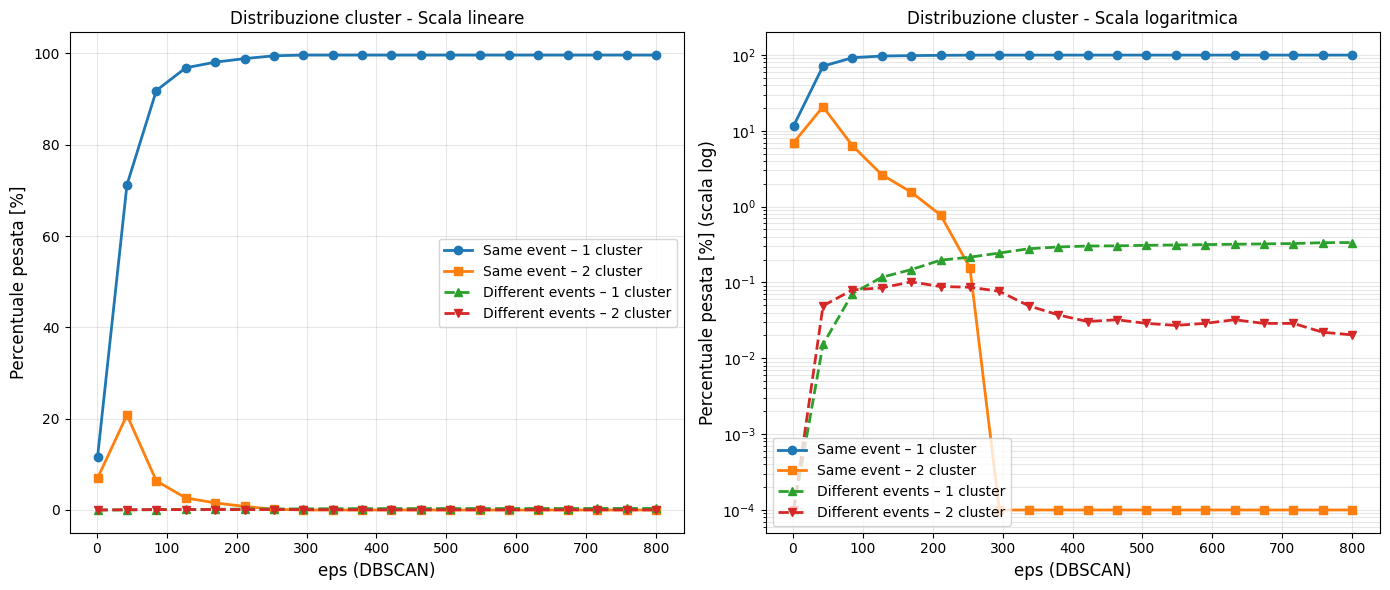


=== Percentuali pesate per alcuni eps ===

eps ≈ 85.1:
  Same event → 1 cluster: 91.8830%
  Same event → 2 cluster: 6.3635%
  Different events → 1 cluster: 0.0713%
  Different events → 2 cluster: 0.0798%
  Totale same: 98.2465%
  Totale different: 0.1511%

eps ≈ 211.3:
  Same event → 1 cluster: 98.8674%
  Same event → 2 cluster: 0.7760%
  Different events → 1 cluster: 0.1970%
  Different events → 2 cluster: 0.0883%
  Totale same: 99.6434%
  Totale different: 0.2853%

eps ≈ 379.5:
  Same event → 1 cluster: 99.6434%
  Same event → 2 cluster: 0.0000%
  Different events → 1 cluster: 0.2938%
  Different events → 2 cluster: 0.0374%
  Totale same: 99.6434%
  Totale different: 0.3311%

eps ≈ 589.7:
  Same event → 1 cluster: 99.6434%
  Same event → 2 cluster: 0.0000%
  Different events → 1 cluster: 0.3158%
  Different events → 2 cluster: 0.0289%
  Totale same: 99.6434%
  Totale different: 0.3447%


In [ ]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)

# ===================== PESI DALLA FINESTRA TEMPORALE =====================
n_same = 22913
n_diff = 82
n_total = 22995

p_same = n_same / n_total  # 0.996
p_diff = n_diff / n_total  # 0.004

print(f"Pesi utilizzati:")
print(f"  p(stesso evento) = {p_same:.4f} ({p_same*100:.2f}%)")
print(f"  p(eventi diversi) = {p_diff:.4f} ({p_diff*100:.2f}%)")

# ===================== LISTE RISULTATI PESATI =====================
p1_real_weighted = []
p2_real_weighted = []
p1_fake_weighted = []
p2_fake_weighted = []

# ===================== REAL (pesato con p_same) =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    # Moltiplica le percentuali per p_same
    p1_real_weighted.append(p_same * 100 * n_1cl / n_evt if n_evt > 0 else 0)
    p2_real_weighted.append(p_same * 100 * n_2cl / n_evt if n_evt > 0 else 0)

# ===================== FAKE (pesato con p_diff) =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    # Moltiplica le percentuali per p_diff
    p1_fake_weighted.append(p_diff * 100 * n_1cl / n_evt if n_evt > 0 else 0)
    p2_fake_weighted.append(p_diff * 100 * n_2cl / n_evt if n_evt > 0 else 0)

# ===================== PLOT CON SCALA LOGARITMICA =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Scala normale (per vedere i same events)
ax1.plot(eps_values, p1_real_weighted, marker='o', linewidth=2, label="Same event – 1 cluster")
ax1.plot(eps_values, p2_real_weighted, marker='s', linewidth=2, label="Same event – 2 cluster")
ax1.plot(eps_values, p1_fake_weighted, marker='^', linewidth=2, linestyle='--', label="Different events – 1 cluster")
ax1.plot(eps_values, p2_fake_weighted, marker='v', linewidth=2, linestyle='--', label="Different events – 2 cluster")

ax1.set_xlabel("eps (DBSCAN)", fontsize=12)
ax1.set_ylabel("Percentuale pesata [%]", fontsize=12)
ax1.set_title("Distribuzione cluster - Scala lineare")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Scala logaritmica (per vedere i different events)
# Sostituisci gli zeri con un valore molto piccolo per la scala log
p1_real_log = [max(p, 1e-4) for p in p1_real_weighted]
p2_real_log = [max(p, 1e-4) for p in p2_real_weighted]
p1_fake_log = [max(p, 1e-4) for p in p1_fake_weighted]
p2_fake_log = [max(p, 1e-4) for p in p2_fake_weighted]

ax2.plot(eps_values, p1_real_log, marker='o', linewidth=2, label="Same event – 1 cluster")
ax2.plot(eps_values, p2_real_log, marker='s', linewidth=2, label="Same event – 2 cluster")
ax2.plot(eps_values, p1_fake_log, marker='^', linewidth=2, linestyle='--', label="Different events – 1 cluster")
ax2.plot(eps_values, p2_fake_log, marker='v', linewidth=2, linestyle='--', label="Different events – 2 cluster")

ax2.set_xlabel("eps (DBSCAN)", fontsize=12)
ax2.set_ylabel("Percentuale pesata [%] (scala log)", fontsize=12)
ax2.set_title("Distribuzione cluster - Scala logaritmica")
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

plt.tight_layout()
plt.show()

# ===================== STAMPA VALORI PER ALCUNI EPS =====================
print("\n=== Percentuali pesate per alcuni eps ===")
for eps_target in [100, 200, 400, 600]:
    idx = np.argmin(np.abs(eps_values - eps_target))
    print(f"\neps ≈ {eps_values[idx]:.1f}:")
    print(f"  Same event → 1 cluster: {p1_real_weighted[idx]:.4f}%")
    print(f"  Same event → 2 cluster: {p2_real_weighted[idx]:.4f}%")
    print(f"  Different events → 1 cluster: {p1_fake_weighted[idx]:.4f}%")
    print(f"  Different events → 2 cluster: {p2_fake_weighted[idx]:.4f}%")
    print(f"  Totale same: {p1_real_weighted[idx] + p2_real_weighted[idx]:.4f}%")
    print(f"  Totale different: {p1_fake_weighted[idx] + p2_fake_weighted[idx]:.4f}%")

KeyError: "None of [Index(['event_line', 'mcrun_line'], dtype='object')] are in the [columns]"

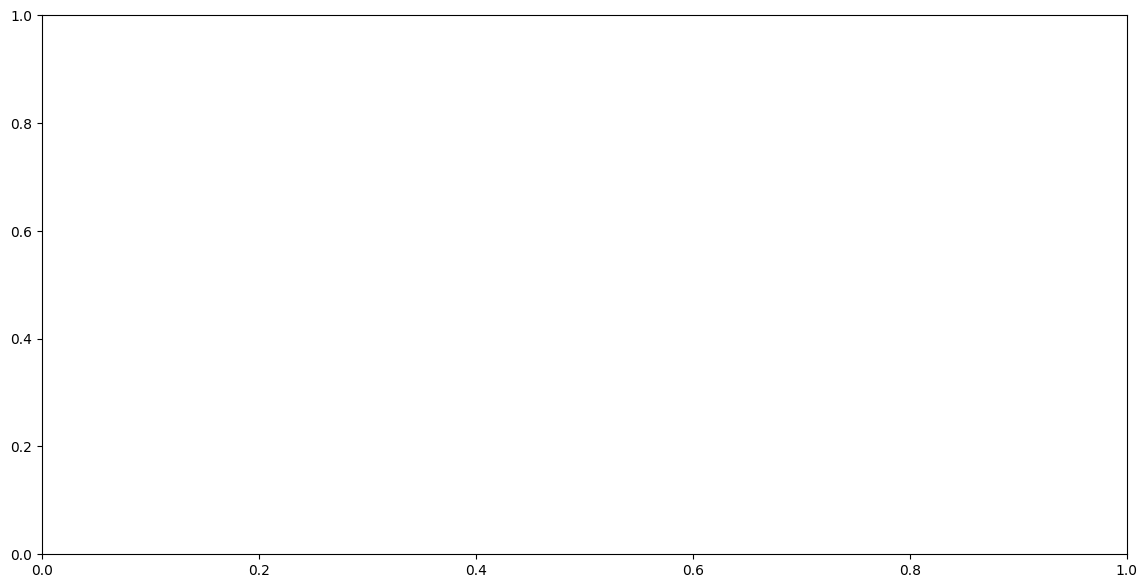

In [ ]:
# ==================== PLOT UNICO ====================

fig, ax = plt.subplots(figsize=(14, 7))

# Liste per accumulare tutte le distanze
all_dist_same = []
all_dist_other = []

fevents = df_dist_hg_f["fevent"].unique()

for fev in fevents:
    df_fev = df_dist_hg_f[df_dist_hg_f["fevent"] == fev]
    
    # Trova le 2 coppie (event, mcrun) in questo fevent
    pairs = df_fev[["event_line", "mcrun_line"]].drop_duplicates().values
    print(f"\nfevent {fev}: {pairs}")
    
    # Per ogni cluster
    for cluster_id in df_fev["cluster"].unique():
        df_cluster = df_fev[df_fev["cluster"] == cluster_id]
        
        # Trova quale (event,mcrun) appartiene a questo cluster
        avg_dists = []
        for evt, mc in pairs:
            mask = (df_cluster["event_line"] == evt) & (df_cluster["mcrun_line"] == mc)
            dists = df_cluster.loc[mask, "d_weight"].values
            dists = dists[np.isfinite(dists) & (dists > 0)]
            avg_dists.append(np.median(dists) if len(dists) > 0 else np.inf)
        
        cluster_pair_idx = np.argmin(avg_dists)
        cluster_evt, cluster_mc = pairs[cluster_pair_idx]
        
        print(f"  Cluster {cluster_id} → evt={cluster_evt}, mc={cluster_mc}")
        
        # Separa SAME vs OTHER
        mask_same = (df_cluster["event_line"] == cluster_evt) & (df_cluster["mcrun_line"] == cluster_mc)
        mask_other = ~mask_same
        
        dist_same = df_cluster.loc[mask_same, "d_weight"].values
        dist_other = df_cluster.loc[mask_other, "d_weight"].values
        
        dist_same = dist_same[np.isfinite(dist_same) & (dist_same > 0)]
        dist_other = dist_other[np.isfinite(dist_other) & (dist_other > 0)]
        
        # Accumula
        all_dist_same.extend(dist_same)
        all_dist_other.extend(dist_other)

# Converti in array
all_dist_same = np.array(all_dist_same)
all_dist_other = np.array(all_dist_other)

print(f"\nTotale SAME: {len(all_dist_same)}")
print(f"Totale OTHER: {len(all_dist_other)}")

# Plot unico
if len(all_dist_same) > 0 or len(all_dist_other) > 0:
    max_dist = max(
        all_dist_same.max() if len(all_dist_same) > 0 else 1,
        all_dist_other.max() if len(all_dist_other) > 0 else 1
    )
    bins = np.logspace(-3, np.log10(max_dist), 60)
    
    if len(all_dist_same) > 0:
        ax.hist(all_dist_same, bins=bins, alpha=0.6,
                label=f'Cluster → sue rette (n={len(all_dist_same)})',
                color='blue', edgecolor='black', linewidth=0.5)
    
    if len(all_dist_other) > 0:
        ax.hist(all_dist_other, bins=bins, alpha=0.6,
                label=f'Cluster → altre rette (n={len(all_dist_other)})',
                color='red', edgecolor='black', linewidth=0.5)

ax.axvline(1e-3, color='yellow', linestyle='--', linewidth=2, alpha=0.7, label='~0 threshold')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distanza (mm)", fontsize=13)
ax.set_ylabel("Conteggio", fontsize=13)
ax.set_title("Diagnostica Clustering - HG (tutti i fevents)", fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [ ]:
threshold =0  # distanza massima per considerare la retta parte del cluster/evento

# ======================= HG =======================
dist_hg_tagged = []

for (event, mcrun), df_evt in df_dist_hg.groupby(["event","mcrun"]):
    # ciclo sui cluster già calcolati
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        # centroide del cluster
        P_mean = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]  # distanza già calcolata dal cluster
            tag = "this_event" if dm <= threshold else "other_event"

            dist_hg_tagged.append({
                "revent":row["revent"],
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_median": P_median.copy()
            })

df_dist_hg_tagged = pd.DataFrame(dist_hg_tagged)


# ======================= LG =======================
dist_lg_tagged = []

for (event, mcrun), df_evt in df_dist_lg.groupby(["event","mcrun"]):
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        P_median = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]
            tag = "this_event" if dm <= threshold else "other_event"

            dist_lg_tagged.append({
                "revent":row["revent"],
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_mean": P_mean.copy()
            })

df_dist_lg_tagged = pd.DataFrame(dist_lg_tagged)


In [ ]:
##=============================0 FAKE EVENT ===========================================
dist_hg_tagged = []
for fevent, df_evt in df_dist_hg_f.groupby("fevent"):
    # ciclo sui cluster già calcolati
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        # centroide del cluster
        P_mean = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]  # distanza già calcolata dal cluster
            tag = "this_event" if dm <= threshold else "other_event"

            dist_hg_tagged.append({
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_median": P_median.copy()
            })

df_dist_hg_tagged_f = pd.DataFrame(dist_hg_tagged)


# ======================= LG =======================
dist_lg_tagged = []

for fevent, df_evt in df_dist_lg_f.groupby("fevent"):
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        P_median = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]
            tag = "this_event" if dm <= threshold else "other_event"

            dist_lg_tagged.append({
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_mean": P_mean.copy()
            })

df_dist_lg_tagged_f = pd.DataFrame(dist_lg_tagged)

In [ ]:
'''
def build_tagged_df(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per-retta corretto.

    - per ogni revent:
        - ogni retta sceglie la distanza MINIMA tra tutti i cluster
        - se min_dist <= threshold → retta appartiene all’evento
    - tutte le rette buone dello stesso revent hanno lo STESSO tag
    - tag = 0 → retta non associata a nessun evento
    """
    df = df_dist.copy()
    tagged_rows = []
    next_tag = 1

    for revent, df_evt in df.groupby("revent"):

        # distanza minima per ogni telescopio
        min_dist = df_evt.groupby("tel")[dist_col].min()

        # telescopi buoni
        good_tel = min_dist[min_dist <= threshold].index

        if len(good_tel) > 0:
            tag = next_tag
            next_tag += 1
        else:
            tag = 0

        for _, row in df_evt.iterrows():
            out = row.to_dict()
            if row["tel"] in good_tel:
                out["tag"] = tag
            else:
                out["tag"] = 0
            tagged_rows.append(out)

    return pd.DataFrame(tagged_rows)
'''

In [ ]:
def build_tagged_df(df_dist, threshold, dist_col="d_median"):
    """
    Tagging per-retta corretto.

    - per ogni revent / fevent:
        - ogni retta sceglie la distanza MINIMA tra tutti i cluster
        - se min_dist <= threshold → retta appartiene all’evento
    - tutte le rette buone dello stesso evento hanno lo STESSO tag
    - tag = 0 → retta non associata a nessun evento
    """

    df = df_dist.copy()

    # colonna unificata per eventi
    if "revent" in df.columns:
        df["event_id"] = df["revent"]
    elif "fevent" in df.columns:
        df["event_id"] = df["fevent"]
    else:
        df["event_id"] = 0  # fallback se non esiste nessuna colonna

    tagged_rows = []
    next_tag = 1

    for event_id, df_evt in df.groupby("event_id"):

        # distanza minima per ogni telescopio
        min_dist = df_evt.groupby("tel")[dist_col].min()

        # telescopi buoni
        good_tel = min_dist[min_dist <= threshold].index

        if len(good_tel) > 0:
            tag = next_tag
            next_tag += 1
        else:
            tag = 0

        for _, row in df_evt.iterrows():
            out = row.to_dict()
            if row["tel"] in good_tel:
                out["tag"] = tag
            else:
                out["tag"] = 0
            tagged_rows.append(out)

    return pd.DataFrame(tagged_rows)

In [ ]:
######## tagged sequenziale
def build_tagged_df_sequential(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per-retta corretto, versione sequenziale.

    - per ogni revent / fevent:
        - per ogni telescopio, controlla una per una le distanze
        - se trova almeno una distanza <= threshold → retta appartiene all'evento
        - altrimenti → tag = 0
    - tutte le rette buone dello stesso evento hanno lo STESSO tag
    """
    df = df_dist.copy()

    # colonna unificata per eventi
    if "revent" in df.columns:
        df["event_id"] = df["revent"]
    elif "fevent" in df.columns:
        df["event_id"] = df["fevent"]
    else:
        df["event_id"] = 0  # fallback se non esiste nessuna colonna

    tagged_rows = []
    next_tag = 1

    for event_id, df_evt in df.groupby("event_id"):

        good_tel = []

        # scansiona telescopi uno per uno
        for tel, df_tel in df_evt.groupby("tel"):
            # scansiona le distanze finché trovi una sotto soglia
            if any(df_tel[dist_col] <= threshold):
                good_tel.append(tel)

        # assegna tag
        if len(good_tel) > 0:
            tag = next_tag
            next_tag += 1
        else:
            tag = 0

        # costruisci le righe taggate
        for _, row in df_evt.iterrows():
            out = row.to_dict()
            out["tag"] = tag if row["tel"] in good_tel else 0
            tagged_rows.append(out)

    return pd.DataFrame(tagged_rows)


In [ ]:
#===========================prova=============================
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


'''
def evaluate_tagging_accuracy(df, tag_col="tag"):
    """
    Valuta quanto bene il clustering riconosce gli eventi reali.
    Considera solo i cluster/eventi riconosciuti (tag > 0).
    """

    # Assicuriamoci che i tag siano numerici
    df[tag_col] = df[tag_col].astype(int)

    # Lista degli eventi MC
    events_mc = df.groupby(["revent", "event", "mcrun"])
    N_true = len(events_mc)

    # Controllo coerenza dei tag per ciascun evento MC
    split_check = events_mc[tag_col].nunique().reset_index(name="n_tag")

    # Considera solo eventi con almeno un tag > 0
    max_tag_per_event = events_mc[tag_col].max().values
    split_check = split_check[max_tag_per_event > 0]

    # N_good = eventi MC con tag coerente (tutti i telescopi hanno stesso tag)
    N_good = (split_check["n_tag"] == 1).sum()

    # N_reco = numero di cluster distinti riconosciuti (tag > 0)
    N_reco = df[df[tag_col] > 0][tag_col].nunique()

    # Accuracy (considera tutti i telescopi)
    y_true = [1] * len(df)
    y_pred = df[tag_col].apply(lambda x: 1 if x > 0 else 0).values
    acc = accuracy_score(y_true, y_pred)

    # Frazioni
    frac_true = N_good / N_true if N_true > 0 else 0
    frac_reco = N_good / N_reco if N_reco > 0 else 0

    result = {
        "accuracy": acc,
        "N_true": N_true,
        "N_good": N_good,
        "N_reco": N_reco,
        "frac_true": frac_true,
        "frac_reco": frac_reco
    }

    return result
'''
def evaluate_tagging_accuracy(df, tag_col="tag"):
    """
    Valuta quanto bene il clustering riconosce gli eventi reali.
    Considera solo i cluster/eventi riconosciuti (tag > 0).
    Funziona sia se c'è 'revent' sia 'fevent'.
    """

    # Assicuriamoci che i tag siano numerici (tag non convertibili diventano 0)
    df[tag_col] = pd.to_numeric(df[tag_col], errors='coerce').fillna(0).astype(int)

    # Scegliamo la colonna dell'evento
    if "revent" in df.columns:
        event_col = "revent"
    elif "fevent" in df.columns:
        event_col = "fevent"
    else:
        event_col = None

    # Lista degli eventi MC
    if event_col:
        events_mc = df.groupby([event_col, "event", "mcrun"])
    else:
        events_mc = df.groupby(["event", "mcrun"])
        
    N_true = len(events_mc)

    # Controllo coerenza dei tag per ciascun evento MC
    split_check = events_mc[tag_col].nunique().reset_index(name="n_tag")

    # Considera solo eventi con almeno un tag > 0
    max_tag_per_event = events_mc[tag_col].max().reset_index(name="max_tag")["max_tag"]
    split_check = split_check[max_tag_per_event > 0]

    # N_good = eventi MC con tag coerente (tutti i telescopi hanno lo stesso tag)
    N_good = (split_check["n_tag"] == 1).sum()

    # N_reco = numero di cluster/eventi ricostruiti (tag > 0)
    N_reco = df[df[tag_col] > 0][tag_col].nunique()

    # Accuracy (considera tutti i telescopi)
    import numpy as np
    y_true = np.ones(len(df))
    y_pred = (df[tag_col] > 0).astype(int).values
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_true, y_pred)

    # Frazioni
    frac_true = N_good / N_true if N_true > 0 else 0
    frac_reco = N_good / N_reco if N_reco > 0 else 0

    result = {
        "accuracy": acc,
        "N_true": N_true,
        "N_good": N_good,
        "N_reco": N_reco,
        "frac_true": frac_true,
        "frac_reco": frac_reco
    }

    return result

df_prova= build_tagged_df(df_dist_hg_f,1000)
result = evaluate_tagging_accuracy(df_prova)

print("Accuracy (tutti i telescopi):      ", result["accuracy"])
print("Eventi MC totali (N_true):         ", result["N_true"])
print("Eventi MC riconosciuti correttamente (N_good):", result["N_good"])
print("Eventi ricostruiti (N_reco):       ", result["N_reco"])
print("Frazione corretti / totali (N_good/N_true): ", result["frac_true"])
print("Frazione corretti / ricostruiti (N_good/N_reco): ", result["frac_reco"])


Accuracy (tutti i telescopi):       1.0
Eventi MC totali (N_true):          394
Eventi MC riconosciuti correttamente (N_good): 394
Eventi ricostruiti (N_reco):        197
Frazione corretti / totali (N_good/N_true):  1.0
Frazione corretti / ricostruiti (N_good/N_reco):  2.0


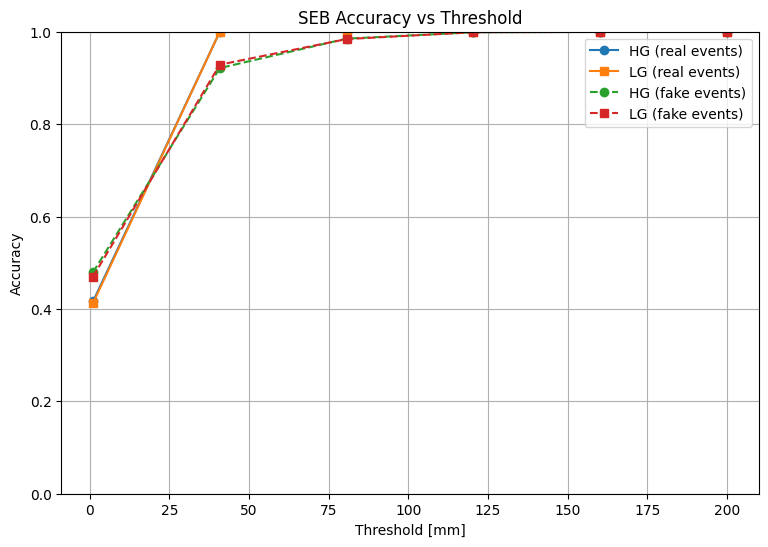

In [ ]:
threshold_values = np.linspace(1, 200, 6)

# Array dove salvare le metriche
acc_hg_real, acc_lg_real = [], []
acc_hg_fake, acc_lg_fake = [], []

# ==================== LOOP PER CALCOLARE LE METRICHE ====================
for thr in threshold_values:

    # HG real
    df_tagged = build_tagged_df(df_dist_hg, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_hg_real.append(result["accuracy"])

    # LG real
    df_tagged = build_tagged_df(df_dist_lg, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_lg_real.append(result["accuracy"])

    # HG fake
    df_tagged = build_tagged_df(df_dist_hg_f, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_hg_fake.append(result["accuracy"])

    # LG fake
    df_tagged = build_tagged_df(df_dist_lg_f, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_lg_fake.append(result["accuracy"])

# ==================== PLOT ACCURACY ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, acc_hg_real, marker='o', label="HG (real events)")
plt.plot(threshold_values, acc_lg_real, marker='s', label="LG (real events)")
plt.plot(threshold_values, acc_hg_fake, marker='o', linestyle='--', label="HG (fake events)")
plt.plot(threshold_values, acc_lg_fake, marker='s', linestyle='--', label="LG (fake events)")

plt.xlabel("Threshold [mm]")
plt.ylabel("Accuracy")
plt.title("SEB Accuracy vs Threshold")
plt.grid(True)
plt.legend()
plt.ylim(0,1)
plt.show()

In [ ]:
'''
# ==================== Threshold da testare ====================
threshold_values = np.linspace(1, 500, 6)

# ==================== Liste per salvare le frazioni ====================
frac_true_hg_real, frac_reco_hg_real = [], []
frac_true_lg_real, frac_reco_lg_real = [], []
frac_true_hg_fake, frac_reco_hg_fake = [], []
frac_true_lg_fake, frac_reco_lg_fake = [], []

# ==================== Loop sui threshold ====================
for thr in threshold_values:

    # ---------- HG real ----------
    df_tagged = build_tagged_df(df_dist_hg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_real.append(res["frac_true"])
    frac_reco_hg_real.append(res["frac_reco"])

    # ---------- LG real ----------
    df_tagged = build_tagged_df(df_dist_lg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_real.append(res["frac_true"])
    frac_reco_lg_real.append(res["frac_reco"])

    # ---------- HG fake ----------
    df_tagged = build_tagged_df(df_dist_hg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_fake.append(res["frac_true"])
    frac_reco_hg_fake.append(res["frac_reco"])

    # ---------- LG fake ----------
    df_tagged = build_tagged_df(df_dist_lg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_fake.append(res["frac_true"])
    frac_reco_lg_fake.append(res["frac_reco"])

# ==================== PLOT N_good / N_true ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_true_hg_real, marker='o', label="HG Real")
plt.plot(threshold_values, frac_true_lg_real, marker='s', label="LG Real")
plt.plot(threshold_values, frac_true_hg_fake, marker='^', label="HG Fake")
plt.plot(threshold_values, frac_true_lg_fake, marker='v', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_true")
plt.title("Frazione Eventi Riconosciuti / Totali (N_good/N_true)")
plt.grid(True)
plt.legend()
#plt.ylim(0,1)
plt.show()

# ==================== PLOT N_good / N_reco ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_reco_hg_real, marker='o', linestyle='-', label="HG Real")
plt.plot(threshold_values, frac_reco_lg_real, marker='s', linestyle='-', label="LG Real")
plt.plot(threshold_values, frac_reco_hg_fake, marker='^', linestyle='--', label="HG Fake")
plt.plot(threshold_values, frac_reco_lg_fake, marker='v', linestyle='--', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_reco")
plt.title("Frazione Eventi Riconosciuti / Ricostruiti (N_good/N_reco)")
plt.grid(True)
plt.legend()
#plt.ylim(0,1)
plt.show()
'''

'\n# ==================== Threshold da testare ====================\nthreshold_values = np.linspace(1, 500, 6)\n\n# ==================== Liste per salvare le frazioni ====================\nfrac_true_hg_real, frac_reco_hg_real = [], []\nfrac_true_lg_real, frac_reco_lg_real = [], []\nfrac_true_hg_fake, frac_reco_hg_fake = [], []\nfrac_true_lg_fake, frac_reco_lg_fake = [], []\n\n# ==================== Loop sui threshold ====================\nfor thr in threshold_values:\n\n    # ---------- HG real ----------\n    df_tagged = build_tagged_df(df_dist_hg, thr, dist_col="d_weight")\n    res = evaluate_tagging_accuracy(df_tagged)\n    frac_true_hg_real.append(res["frac_true"])\n    frac_reco_hg_real.append(res["frac_reco"])\n\n    # ---------- LG real ----------\n    df_tagged = build_tagged_df(df_dist_lg, thr, dist_col="d_weight")\n    res = evaluate_tagging_accuracy(df_tagged)\n    frac_true_lg_real.append(res["frac_true"])\n    frac_reco_lg_real.append(res["frac_reco"])\n\n    # ---------- 

In [ ]:
#prova 
def build_tagged_df_sequential(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per cluster:
    - Per ogni cluster, scansiona sequenzialmente le rette
    - Se distanza <= threshold → assegna il tag del cluster
    - Altrimenti → tag = 0
    
    Ogni cluster ha un tag univoco progressivo.
    """
    df = df_dist.copy()
    
    # Colonna unificata per eventi
    if "revent" in df.columns:
        df["event_id"] = df["revent"]
    elif "fevent" in df.columns:
        df["event_id"] = df["fevent"]
    else:
        df["event_id"] = 0
    
    tagged_rows = []
    next_tag = 1
    
    # Per ogni evento (fevent/revent)
    for event_id, df_evt in df.groupby("event_id"):
        
        # Per ogni cluster in questo evento
        for cluster_id, df_cluster in df_evt.groupby("cluster"):
            
            # Questo cluster riceve un tag univoco
            tag = next_tag
            next_tag += 1
            
            # Scansiona sequenzialmente ogni retta (ogni tel)
            for tel, df_tel in df_cluster.groupby("tel"):
                
                # Prendi la distanza di questa retta da questo cluster
                # (dovrebbe essere una sola riga per tel in questo cluster)
                distances = df_tel[dist_col].values
                
                # Se ALMENO UNA distanza è <= threshold → tag buono
                if any(distances <= threshold):
                    retta_tag = tag
                else:
                    retta_tag = 0
                
                # Salva tutte le righe di questo telescopio con il tag
                for _, row in df_tel.iterrows():
                    out = row.to_dict()
                    out["tag"] = retta_tag
                    tagged_rows.append(out)
    
    return pd.DataFrame(tagged_rows)


# ========== TEST ==========
# df_tagged = build_tagged_df_sequential(df_dist_hg_f, threshold=10.0, dist_col="d_weight")

# print("\nStatistiche tagging:")
# print(f"Tag 0 (rette scartate): {(df_tagged['tag'] == 0).sum()}")
# print(f"Tag > 0 (rette buone): {(df_tagged['tag'] > 0).sum()}")
# print(f"\nNumero di cluster identificati: {df_tagged[df_tagged['tag'] > 0]['tag'].nunique()}")

# # Vedi distribuzione tag
# print("\nConteggio rette per tag:")
# print(df_tagged['tag'].value_counts().sort_index())
def evaluate_tagging_accuracy(df, tag_col="tag"):
    """
    Valuta quanto bene il tagging riconosce gli eventi reali.
    Gestisce sia 'event'/'mcrun' che 'event_line'/'mcrun_line'
    """
    
    df = df.copy()
    df[tag_col] = pd.to_numeric(df[tag_col], errors='coerce').fillna(0).astype(int)
    
    # Identifica colonna evento
    if "revent" in df.columns:
        event_col = "revent"
    elif "fevent" in df.columns:
        event_col = "fevent"
    else:
        print("⚠️ Nessuna colonna revent/fevent trovata!")
        return None
    
    # Identifica colonne event e mcrun (possono avere _line o no)
    if "event_line" in df.columns and "mcrun_line" in df.columns:
        evt_col = "event_line"
        mc_col = "mcrun_line"
    elif "event" in df.columns and "mcrun" in df.columns:
        evt_col = "event"
        mc_col = "mcrun"
    else:
        print("⚠️ Nessuna colonna event/mcrun trovata!")
        print(f"Colonne disponibili: {df.columns.tolist()}")
        return None
    
    # ---------- N_true: conta eventi reali unici ----------
    true_events = df.groupby([event_col, evt_col, mc_col]).size().reset_index(name="count")
    N_true = len(true_events)
    
    print(f"\n{'='*70}")
    print(f"VALUTAZIONE TAGGING")
    print(f"{'='*70}")
    print(f"Eventi reali totali ({evt_col}, {mc_col}): {N_true}")
    
    # ---------- Analisi per cluster (tag > 0) ----------
    df_reco = df[df[tag_col] > 0].copy()
    
    if len(df_reco) == 0:
        print("⚠️ Nessun cluster riconosciuto (tutti tag = 0)!")
        return {
            "N_true": N_true,
            "N_reco": 0,
            "N_good": 0,
            "N_mixed": 0,
            "N_complete": 0,
            "N_split": 0,
            "N_not_reco": N_true,
            "purity": 0,
            "completeness": 0,
            "accuracy": 0
        }
    
    N_reco = df_reco[tag_col].nunique()
    print(f"Cluster riconosciuti (tag > 0): {N_reco}")
    
    # ---------- Analisi purezza cluster ----------
    N_good = 0
    N_mixed = 0
    
    cluster_stats = []
    
    for tag, df_tag in df_reco.groupby(tag_col):
        # Per questo cluster, quanti (event, mcrun) diversi ci sono?
        unique_events = df_tag[[evt_col, mc_col]].drop_duplicates()
        n_events = len(unique_events)
        
        if n_events == 1:
            N_good += 1
            purity = "GOOD"
        else:
            N_mixed += 1
            purity = "MIXED"
        
        cluster_stats.append({
            "tag": tag,
            "n_events": n_events,
            "n_rette": len(df_tag),
            "purity": purity,
            "events": list(unique_events.itertuples(index=False, name=None))
        })
    
    print(f"\nCluster GOOD (un solo evento): {N_good}")
    print(f"Cluster MIXED (più eventi mescolati): {N_mixed}")
    
    # ---------- Analisi completezza eventi ----------
    N_split = 0
    
    event_coverage = []
    
    for (evt_id, evt, mc), df_evt in df.groupby([event_col, evt_col, mc_col]):
        # Quanti tag ha questo evento?
        tags = df_evt[df_evt[tag_col] > 0][tag_col].unique()
        n_tags = len(tags)
        n_rette_totali = len(df_evt)
        n_rette_riconosciute = len(df_evt[df_evt[tag_col] > 0])
        
        if n_tags == 0:
            status = "NOT_RECO"
        elif n_tags == 1:
            status = "COMPLETE"
        else:
            status = "SPLIT"
            N_split += 1
        
        event_coverage.append({
            "event_id": evt_id,
            "event": evt,
            "mcrun": mc,
            "n_tags": n_tags,
            "tags": list(tags),
            "n_rette_totali": n_rette_totali,
            "n_rette_reco": n_rette_riconosciute,
            "status": status
        })
    
    N_complete = sum(1 for e in event_coverage if e["status"] == "COMPLETE")
    N_not_reco = sum(1 for e in event_coverage if e["status"] == "NOT_RECO")
    
    print(f"\nEventi COMPLETE (tutte le rette in 1 cluster): {N_complete}")
    print(f"Eventi SPLIT (rette divise in più cluster): {N_split}")
    print(f"Eventi NOT_RECO (nessuna retta riconosciuta): {N_not_reco}")
    
    # ---------- Metriche finali ----------
    purity = N_good / N_reco if N_reco > 0 else 0
    completeness = N_complete / N_true if N_true > 0 else 0
    total_rette = len(df)
    correct_rette = len(df_reco)
    accuracy = correct_rette / total_rette if total_rette > 0 else 0
    
    print(f"\n{'='*70}")
    print(f"METRICHE")
    print(f"{'='*70}")
    print(f"Purity (cluster puri):        {purity:.2%} ({N_good}/{N_reco})")
    print(f"Completeness (eventi interi): {completeness:.2%} ({N_complete}/{N_true})")
    print(f"Accuracy (rette taggate):     {accuracy:.2%} ({correct_rette}/{total_rette})")
    
    return {
        "N_true": N_true,
        "N_reco": N_reco,
        "N_good": N_good,
        "N_mixed": N_mixed,
        "N_complete": N_complete,
        "N_split": N_split,
        "N_not_reco": N_not_reco,
        "purity": purity,
        "completeness": completeness,
        "accuracy": accuracy,
        "cluster_stats": cluster_stats,
        "event_coverage": event_coverage
    }

# ========== UTILIZZO ==========
# results = evaluate_tagging_accuracy(df_tagged, tag_col="tag")

# # Per vedere dettagli
# import pandas as pd
# print("\nDettaglio cluster:")
# print(pd.DataFrame(results["cluster_stats"]))

# print("\nDettaglio eventi:")
# print(pd.DataFrame(results["event_coverage"]))

In [ ]:
# ==================== Threshold da testare ====================
threshold_values = np.linspace(1, 500, 20)  # Ho aumentato i punti per vedere meglio

# ==================== Liste per salvare le metriche ====================
purity_hg_real, completeness_hg_real = [], []
purity_lg_real, completeness_lg_real = [], []
purity_hg_fake, completeness_hg_fake = [], []
purity_lg_fake, completeness_lg_fake = [], []

# Numero di eventi riconosciuti
n_reco_hg_real, n_reco_lg_real = [], []
n_reco_hg_fake, n_reco_lg_fake = [], []

# ==================== Loop sui threshold ====================
print("Testing thresholds...")
for i, thr in enumerate(threshold_values):
    print(f"\n{'='*70}")
    print(f"Threshold {i+1}/{len(threshold_values)}: {thr:.1f} mm")
    print(f"{'='*70}")

    # ---------- HG real ----------
    print("\n[HG REAL]")
    df_tagged = build_tagged_df_sequential(df_dist_hg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_hg_real.append(res["purity"])
    completeness_hg_real.append(res["completeness"])
    n_reco_hg_real.append(res["N_reco"])

    # ---------- LG real ----------
    print("\n[LG REAL]")
    df_tagged = build_tagged_df_sequential(df_dist_lg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_lg_real.append(res["purity"])
    completeness_lg_real.append(res["completeness"])
    n_reco_lg_real.append(res["N_reco"])

    # ---------- HG fake ----------
    print("\n[HG FAKE]")
    df_tagged = build_tagged_df_sequential(df_dist_hg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_hg_fake.append(res["purity"])
    completeness_hg_fake.append(res["completeness"])
    n_reco_hg_fake.append(res["N_reco"])

    # ---------- LG fake ----------
    print("\n[LG FAKE]")
    df_tagged = build_tagged_df_sequential(df_dist_lg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_lg_fake.append(res["purity"])
    completeness_lg_fake.append(res["completeness"])
    n_reco_lg_fake.append(res["N_reco"])

# ==================== PLOT 1: PURITY (cluster puri) ====================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_values, purity_hg_real, marker='o', linestyle='-', linewidth=2, 
        label="HG Real", color='blue')
ax.plot(threshold_values, purity_lg_real, marker='s', linestyle='-', linewidth=2, 
        label="LG Real", color='cyan')
ax.plot(threshold_values, purity_hg_fake, marker='^', linestyle='--', linewidth=2, 
        label="HG Fake", color='red')
ax.plot(threshold_values, purity_lg_fake, marker='v', linestyle='--', linewidth=2, 
        label="LG Fake", color='orange')

ax.set_xlabel("Threshold [mm]", fontsize=13)
ax.set_ylabel("Purity (N_good / N_reco)", fontsize=13)
ax.set_title("Purezza Cluster: frazione di cluster con UN SOLO evento", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# ==================== PLOT 2: COMPLETENESS (eventi completi) ====================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_values, completeness_hg_real, marker='o', linestyle='-', linewidth=2, 
        label="HG Real", color='blue')
ax.plot(threshold_values, completeness_lg_real, marker='s', linestyle='-', linewidth=2, 
        label="LG Real", color='cyan')
ax.plot(threshold_values, completeness_hg_fake, marker='^', linestyle='--', linewidth=2, 
        label="HG Fake", color='red')
ax.plot(threshold_values, completeness_lg_fake, marker='v', linestyle='--', linewidth=2, 
        label="LG Fake", color='orange')

ax.set_xlabel("Threshold [mm]", fontsize=13)
ax.set_ylabel("Completeness (N_complete / N_true)", fontsize=13)
ax.set_title("Completezza: frazione di eventi COMPLETAMENTE ricostruiti in 1 cluster", 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# ==================== PLOT 3: Numero cluster riconosciuti ====================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_values, n_reco_hg_real, marker='o', linestyle='-', linewidth=2, 
        label="HG Real", color='blue')
ax.plot(threshold_values, n_reco_lg_real, marker='s', linestyle='-', linewidth=2, 
        label="LG Real", color='cyan')
ax.plot(threshold_values, n_reco_hg_fake, marker='^', linestyle='--', linewidth=2, 
        label="HG Fake", color='red')
ax.plot(threshold_values, n_reco_lg_fake, marker='v', linestyle='--', linewidth=2, 
        label="LG Fake", color='orange')

ax.set_xlabel("Threshold [mm]", fontsize=13)
ax.set_ylabel("N_reco (numero cluster)", fontsize=13)
ax.set_title("Numero di cluster riconosciuti (tag > 0)", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================== PLOT 4: Confronto Purity vs Completeness ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Real events
ax1.plot(threshold_values, purity_hg_real, marker='o', linestyle='-', linewidth=2, 
         label="Purity HG", color='blue')
ax1.plot(threshold_values, completeness_hg_real, marker='o', linestyle='--', linewidth=2, 
         label="Completeness HG", color='blue', alpha=0.6)
ax1.plot(threshold_values, purity_lg_real, marker='s', linestyle='-', linewidth=2, 
         label="Purity LG", color='cyan')
ax1.plot(threshold_values, completeness_lg_real, marker='s', linestyle='--', linewidth=2, 
         label="Completeness LG", color='cyan', alpha=0.6)

ax1.set_xlabel("Threshold [mm]", fontsize=12)
ax1.set_ylabel("Frazione", fontsize=12)
ax1.set_title("Eventi REALI", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim([0, 1.05])

# Fake events
ax2.plot(threshold_values, purity_hg_fake, marker='^', linestyle='-', linewidth=2, 
         label="Purity HG", color='red')
ax2.plot(threshold_values, completeness_hg_fake, marker='^', linestyle='--', linewidth=2, 
         label="Completeness HG", color='red', alpha=0.6)
ax2.plot(threshold_values, purity_lg_fake, marker='v', linestyle='-', linewidth=2, 
         label="Purity LG", color='orange')
ax2.plot(threshold_values, completeness_lg_fake, marker='v', linestyle='--', linewidth=2, 
         label="Completeness LG", color='orange', alpha=0.6)

ax2.set_xlabel("Threshold [mm]", fontsize=12)
ax2.set_ylabel("Frazione", fontsize=12)
ax2.set_title("Eventi FAKE", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Testing thresholds...

Threshold 1/20: 1.0 mm

[HG REAL]

VALUTAZIONE TAGGING
Eventi reali totali (event, mcrun): 691
Cluster riconosciuti (tag > 0): 780

Cluster GOOD (un solo evento): 780
Cluster MIXED (più eventi mescolati): 0

Eventi COMPLETE (tutte le rette in 1 cluster): 408
Eventi SPLIT (rette divise in più cluster): 164
Eventi NOT_RECO (nessuna retta riconosciuta): 119

METRICHE
Purity (cluster puri):        100.00% (780/780)
Completeness (eventi interi): 59.04% (408/691)
Accuracy (rette taggate):     26.23% (1552/5917)

[LG REAL]

VALUTAZIONE TAGGING
Eventi reali totali (event, mcrun): 692
Cluster riconosciuti (tag > 0): 803

Cluster GOOD (un solo evento): 803
Cluster MIXED (più eventi mescolati): 0

Eventi COMPLETE (tutte le rette in 1 cluster): 375
Eventi SPLIT (rette divise in più cluster): 190
Eventi NOT_RECO (nessuna retta riconosciuta): 127

METRICHE
Purity (cluster puri):        100.00% (803/803)
Completeness (eventi interi): 54.19% (375/692)
Accuracy (rette taggate):  

KeyboardInterrupt: 

In [ ]:
# ==================== Threshold da testare ====================
threshold_values = np.linspace(1, 500, 6)

# ==================== Liste per salvare le frazioni ====================
frac_true_hg_real, frac_reco_hg_real = [], []
frac_true_lg_real, frac_reco_lg_real = [], []
frac_true_hg_fake, frac_reco_hg_fake = [], []
frac_true_lg_fake, frac_reco_lg_fake = [], []

# ==================== Loop sui threshold ====================
for thr in threshold_values:

    # ---------- HG real ----------
    df_tagged = build_tagged_df_sequential(df_dist_hg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_real.append(res["frac_true"])
    frac_reco_hg_real.append(res["frac_reco"])

    # ---------- LG real ----------
    df_tagged = build_tagged_df_sequential(df_dist_lg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_real.append(res["frac_true"])
    frac_reco_lg_real.append(res["frac_reco"])

    # ---------- HG fake ----------
    df_tagged = build_tagged_df_sequential(df_dist_hg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_fake.append(res["frac_true"])
    frac_reco_hg_fake.append(res["frac_reco"])

    # ---------- LG fake ----------
    df_tagged = build_tagged_df_sequential(df_dist_lg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_fake.append(res["frac_true"])
    frac_reco_lg_fake.append(res["frac_reco"])

# ==================== PLOT N_good / N_true ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_true_hg_real, marker='o', label="HG Real")
plt.plot(threshold_values, frac_true_lg_real, marker='s', label="LG Real")
plt.plot(threshold_values, frac_true_hg_fake, marker='^', label="HG Fake")
plt.plot(threshold_values, frac_true_lg_fake, marker='v', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_true")
plt.title("Frazione Eventi Riconosciuti / Totali (N_good/N_true)")
plt.grid(True)
plt.legend()
plt.show()

# ==================== PLOT N_good / N_reco ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_reco_hg_real, marker='o', linestyle='-', label="HG Real")
plt.plot(threshold_values, frac_reco_lg_real, marker='s', linestyle='-', label="LG Real")
plt.plot(threshold_values, frac_reco_hg_fake, marker='^', linestyle='--', label="HG Fake")
plt.plot(threshold_values, frac_reco_lg_fake, marker='v', linestyle='--', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_reco")
plt.title("Frazione Eventi Riconosciuti / Ricostruiti (N_good/N_reco)")
plt.grid(True)
plt.legend()
plt.show()


KeyError: 'event_line'